# Notebook 02 : Exploratory Data Analysis

**Project:** Thematic Evolution of French Electoral Manifestos (1973–1993)  
**Course:** Machine Learning for NLP - ENSAE Paris, 2025–2026  
**Author:** Gabriel Orsatti

---

This notebook performs three key tasks:

1. **Text preprocessing** : cleaning, tokenization, and stopword removal (as introduced in *Chapter I - Vector Representations*)
2. **Feature engineering** : party family classification and BERT-based profession mapping (leveraging *Chapter VII - Transformers*)
3. **Exploratory visualization** : corpus structure, socio-demographic profiles, and temporal trends

The input is `df_complet.pkl` produced in Notebook 01. The output is `df_explore.pkl`, enriched with cleaned text, tokens, party families, and PCS profession categories.

---

## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
from pathlib import Path
from collections import Counter
import re
import string
import os
import json
import urllib.request

df = pd.read_pickle("../data/df_complet.pkl")
print(f"DataFrame loaded: {len(df):,} rows × {len(df.columns)} columns")

DataFrame loaded: 21,697 rows × 47 columns


---

## 2. Initial Descriptive Statistics

Before any transformation, let us understand the raw structure of the corpus: how many documents per year, what parties are represented, and what the demographic breakdown looks like.

### 2.1 Corpus composition

In [2]:
print("=== Documents per year ===")
print(df['year'].value_counts().sort_index())

print("\n=== Documents per election type ===")
print(df['election_type'].value_counts())

print("\n=== Top 15 parties (titulaire-soutien) ===")
print(df['titulaire-soutien'].value_counts().head(15))

=== Documents per year ===
year
1973    3921
1978    5030
1981    3182
1988    3628
1993    5936
Name: count, dtype: int64

=== Documents per election type ===
election_type
legislatives    21697
Name: count, dtype: int64

=== Top 15 parties (titulaire-soutien) ===
titulaire-soutien
non mentionné                                                          4040
Parti communiste français                                              2474
Parti socialiste                                                       1735
Front national                                                         1366
Lutte ouvrière                                                         1023
Rassemblement pour la République;Union pour la démocratie française     764
Rassemblement pour la République                                        637
Union pour la démocratie française;Rassemblement pour la République     455
Parti socialiste unifié                                                 441
Nouveaux écologistes du rassembl

Note that `non mentionné` (not specified) accounts for ~4,000 entries, which we will handle through our party family classification below.

### 2.2 Demographic overview

In [3]:
print("=== Gender distribution ===")
print(df['titulaire-sexe'].value_counts())

print("\n=== Age brackets ===")
print(df['titulaire-age-tranche'].value_counts())

=== Gender distribution ===
titulaire-sexe
homme            18171
femme             2160
non déterminé      836
Name: count, dtype: int64

=== Age brackets ===
titulaire-age-tranche
non mentionné         13232
entre 40 et 49 ans     2742
entre 30 et 39 ans     2589
entre 50 et 59 ans     1266
entre 20 et 29 ans     1058
entre 60 et 69 ans      264
entre 70 et 79 ans       16
Name: count, dtype: int64


The gender imbalance is striking: over 82% of candidates are male. The age data is largely missing, which limits age-based analyses to a subset of the corpus.

---

## 3. Text Preprocessing

As discussed in the course (*Chapter I, Bag-of-Words*), the first step of any text-based pipeline is **preprocessing**: lowercasing, punctuation removal, and stopword filtering. These operations reduce the dimensionality of the vocabulary and focus on content-bearing words.

### 3.1 Text cleaning

In [4]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)

print("=== Raw text sample ===")
print(df['text'].iloc[0][:300])
print("\n=== Cleaned text sample ===")
print(df['text_clean'].iloc[0][:300])

=== Raw text sample ===
Sciences Po / fonds CEVIPOF
REPUBLIQUE FRANÇAISE
DEPARTEMENT DE LA HAUTE-SAVOIE
3e CIRCONSCRIPTION ANNEMASSE-CHAMONIX
SCRUTIN DE BALLOTTAGE DU 11 MARS 1973
Lucien COUTANT CANDIDAT DU MOUVEMENT REFORMATEUR
ELECTRICES, ELECTEURS,
Je remercie vivement les 11.534 électrices et électeurs qui m'ont témoig

=== Cleaned text sample ===
sciences po fonds cevipof republique française departement de la hautesavoie e circonscription annemassechamonix scrutin de ballottage du mars lucien coutant candidat du mouvement reformateur electrices electeurs je remercie vivement les électrices et électeurs qui mont témoigné leur confiance au pr


The cleaning pipeline performs four operations: lowercasing, newline removal, punctuation stripping, and digit removal. This is a standard Bag-of-Words preprocessing approach. Note that we do **not** apply lemmatization at this stage, we will experiment with it in the topic modeling notebook.

### 3.2 Tokenization and stopword removal

In [5]:
STOPWORDS_FR = {
    'le', 'la', 'les', 'de', 'des', 'du', 'un', 'une', 'et', 'en', 'à',
    'au', 'aux', 'ce', 'ces', 'que', 'qui', 'dans', 'pour', 'par', 'sur',
    'avec', 'son', 'ses', 'sa', 'se', 'ne', 'pas', 'nous', 'vous', 'ils',
    'est', 'sont', 'ont', 'été', 'être', 'avoir', 'fait', 'faire', 'plus',
    'tout', 'tous', 'toute', 'toutes', 'mais', 'ou', 'où', 'si', 'leur',
    'leurs', 'elle', 'elles', 'il', 'je', 'me', 'mon', 'ma', 'mes',
    'notre', 'nos', 'votre', 'vos', 'même', 'aussi', 'bien', 'peut',
    'cette', 'cet', 'dont', 'comme', 'sans', 'entre', 'très', 'après',
    'avant', 'autres', 'autre', 'encore', 'quand', 'car', 'donc',
    'sera', 'été', 'non', 'oui', 'puis', 'ici', 'là',
    'ya', 'ça', 'cela', 'ceci', 'on', 'ny', 'na', 'ni',
    'circonscription', 'candidat', 'candidate', 'élections', 'législatives',
    'république', 'française', 'france', 'département', 'juin', 'mars',
    'tour', 'scrutin', 'vote', 'voter', 'électeurs', 'cest', 'dune', 'électeur'
}

def tokenize(text):
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS_FR and len(t) > 2]

df['tokens'] = df['text_clean'].apply(tokenize)
df['n_tokens'] = df['tokens'].apply(len)

print(f"Mean tokens per document: {df['n_tokens'].mean():.0f}")
print(f"Token sample: {df['tokens'].iloc[0][:20]}")

Mean tokens per document: 353
Token sample: ['sciences', 'fonds', 'cevipof', 'republique', 'departement', 'hautesavoie', 'annemassechamonix', 'ballottage', 'lucien', 'coutant', 'mouvement', 'reformateur', 'electrices', 'electeurs', 'remercie', 'vivement', 'électrices', 'mont', 'témoigné', 'confiance']


Our stopword list includes standard French function words **plus** domain-specific terms that appear in virtually every manifesto (`circonscription`, `candidat`, `élections`, etc.). These carry no discriminative information for topic modeling, as noted in the course's discussion of TF-IDF: terms with very high document frequency have near-zero IDF weight.

### 3.3 Most frequent words

In [6]:
def get_top_words(df_subset, n=20):
    all_tokens = [token for tokens in df_subset['tokens'] for token in tokens]
    return Counter(all_tokens).most_common(n)

print("=== Top 20 global words ===")
for word, count in get_top_words(df):
    print(f"  {word}: {count:,}")

=== Top 20 global words ===
  fonds: 47,355
  politique: 42,184
  ans: 40,154
  gauche: 39,799
  cevipof: 38,236
  parti: 34,240
  sciences: 31,294
  travailleurs: 29,573
  français: 29,396
  contre: 27,202
  vie: 26,953
  majorité: 25,545
  faut: 25,265
  pays: 24,739
  candidats: 23,386
  droite: 22,903
  travail: 21,781
  suppléant: 21,387
  socialiste: 20,348
  nationale: 20,021


---

## 4. Feature Engineering

### 4.1 Party family classification

The raw `titulaire-soutien` field contains hundreds of unique party labels (including coalitions like `RPR;UDF`). We map these to broad political families for tractable cross-analysis.

In [7]:
def classify_party(soutien):
    if not isinstance(soutien, str):
        return 'Autre'
    soutien = soutien.lower()
    if any(x in soutien for x in ['communiste', 'pcf']):
        return 'PCF'
    if any(x in soutien for x in ['socialiste', 'ps ', 'parti socialiste']):
        return 'PS'
    if any(x in soutien for x in ['rassemblement pour la république', 'rpr', 'gaulliste']):
        return 'RPR'
    if any(x in soutien for x in ['union pour la démocratie française', 'udf']):
        return 'UDF'
    if any(x in soutien for x in ['front national', 'fn']):
        return 'FN'
    if any(x in soutien for x in ['écologi', 'vert']):
        return 'Ecologistes'
    if any(x in soutien for x in ['radical']):
        return 'Radicaux'
    if 'non mentionné' in soutien:
        return 'Non mentionné'
    return 'Autre'

df['parti_famille'] = df['titulaire-soutien'].apply(classify_party)

print("=== Party family distribution ===")
print(df['parti_famille'].value_counts())

=== Party family distribution ===
parti_famille
Autre            5229
Non mentionné    4040
PCF              3485
PS               3309
RPR              2389
FN               1478
Ecologistes      1248
UDF               445
Radicaux           74
Name: count, dtype: int64


### 4.2 Profession classification with BERT (zero-shot)

The `titulaire-profession` field contains over 2,000 unique free-text entries (e.g., *"professeur agrégé de lettres"*, *"directeur commercial adjoint"*). A keyword-based approach would miss many variants. Instead, we leverage a **zero-shot classification** model based on XLM-RoBERTa (as discussed in *Chapter VII: Transformers*), which can assign each profession to one of 15 PCS-inspired categories without any task-specific training data.

The model (`joeddav/xlm-roberta-large-xnli`) uses the Natural Language Inference (NLI) paradigm: for each profession string, it evaluates the hypothesis *"This person works as a [category]"* and returns the most probable category.

**Performance note:** Classification is run only once. Results are cached to `profession_pcs_mapping.json` for subsequent runs.

In [11]:
pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 8.1 MB/s  0:00:56m0:00:0100:03m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 7.7 MB/s  0:00:47m0:00:0100:02m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 3.4 MB/s  0:00:36m0:00:0100:05m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 87.9 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 93.7 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 90.4 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 13.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 93.3 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 88.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 70.4 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [12]:
pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 80.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 50.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 80.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 82.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [transformers] [transformers]ub]
Note: you may need to restart the kernel to use updated packages.


In [13]:
CACHE_PATH = "../data/profession_pcs_mapping.json"

PCS_CATEGORIES = [
    "Agriculteur, exploitant agricole",
    "Artisan, commerçant, chef d'entreprise",
    "Profession médicale ou paramédicale",
    "Profession juridique",
    "Enseignant, chercheur, universitaire",
    "Cadre supérieur, ingénieur",
    "Cadre moyen, technicien",
    "Employé, fonctionnaire",
    "Ouvrier",
    "Journaliste, artiste, communication",
    "Militaire, policier, sécurité",
    "Profession commerciale, vente",
    "Étudiant, retraité, sans emploi",
    "Permanent politique ou syndical",
    "Profession religieuse",
]

if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'r', encoding='utf-8') as f:
        results = json.load(f)
    # Check if new professions from 1973/1978 are missing from the cache
    unique_professions_all = df['titulaire-profession'].dropna().unique()
    missing = [p for p in unique_professions_all
               if isinstance(p, str) and p.lower().strip() not in ['non mentionné', '']
               and p not in results]
    if missing:
        print(f"Cache loaded but {len(missing)} new professions not yet classified → will classify them.")
        needs_classification = True
    else:
        needs_classification = False
        print(f"Cache loaded: {len(results)} professions mapped from {CACHE_PATH} (all professions covered ✓)")
else:
    needs_classification = True

if needs_classification:
    print("Launching BERT classification for new/uncached professions...")
    print("(Results will be merged into the cache for future use)\n")

    try:
        import sentencepiece
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install",
                               "sentencepiece", "protobuf", "--quiet"])
        print("sentencepiece installed - RESTART THE KERNEL then re-run this cell.")
        raise SystemExit("Kernel restart required after sentencepiece installation.")

    import torch
    from transformers import XLMRobertaTokenizer, AutoModelForSequenceClassification, pipeline
    from tqdm import tqdm

    tokenizer = XLMRobertaTokenizer.from_pretrained("joeddav/xlm-roberta-large-xnli")
    model = AutoModelForSequenceClassification.from_pretrained("joeddav/xlm-roberta-large-xnli")

    classifier = pipeline(
        "zero-shot-classification",
        model=model,
        tokenizer=tokenizer,
        device=-1
    )

    unique_professions = df['titulaire-profession'].dropna().unique()
    # If a partial cache exists, only classify what's missing
    if not os.path.exists(CACHE_PATH):
        results = {}
        to_classify = [p for p in unique_professions
                       if isinstance(p, str) and p.lower().strip() not in ['non mentionné', '']]
    else:
        to_classify = missing  # only the new professions from 1973/1978
    print(f"Unique professions to classify: {len(to_classify)}")
    for i in tqdm(range(0, len(to_classify), 16), desc="Classification"):
        batch = to_classify[i:i+16]
        for profession in batch:
            try:
                result = classifier(
                    profession,
                    candidate_labels=PCS_CATEGORIES,
                    hypothesis_template="Cette personne travaille comme {}."
                )
                results[profession] = result['labels'][0]
            except Exception as e:
                results[profession] = 'Autre'

    for p in unique_professions:
        if p not in results:
            results[p] = 'Non renseigné'

    with open(CACHE_PATH, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"\nCache updated and saved to {CACHE_PATH}")

# Apply mapping
df['profession_pcs'] = df['titulaire-profession'].map(results)
df['profession_pcs'] = df['profession_pcs'].fillna('Non renseigné')

print("\n=== PCS category distribution ===\n")
pcs_counts = df['profession_pcs'].value_counts()
for cat, count in pcs_counts.items():
    pct = count / len(df) * 100
    print(f"  {cat:50s} {count:5d}  ({pct:5.1f}%)")

Cache loaded but 1365 new professions not yet classified → will classify them.
Launching BERT classification for new/uncached professions...
(Results will be merged into the cache for future use)



/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 393/393 [00:00<00:00, 3802.85it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Unique professions to classify: 1365


Classification: 100%|██████████| 86/86 [2:02:40<00:00, 85.58s/it]


Cache updated and saved to ../data/profession_pcs_mapping.json

=== PCS category distribution ===

  Non renseigné                                      10011  ( 46.1%)
  Enseignant, chercheur, universitaire                2716  ( 12.5%)
  Profession juridique                                2085  (  9.6%)
  Employé, fonctionnaire                              1925  (  8.9%)
  Ouvrier                                             1548  (  7.1%)
  Cadre supérieur, ingénieur                          1050  (  4.8%)
  Cadre moyen, technicien                              680  (  3.1%)
  Profession commerciale, vente                        616  (  2.8%)
  Agriculteur, exploitant agricole                     484  (  2.2%)
  Journaliste, artiste, communication                  163  (  0.8%)
  Profession religieuse                                134  (  0.6%)
  Profession médicale ou paramédicale                   91  (  0.4%)
  Artisan, commerçant, chef d'entreprise                88  (  0.4%)
  P

The BERT classifier successfully maps the 2,000+ raw profession strings into 15 interpretable categories. Teachers and researchers form the largest group, consistent with the known over-representation of public-sector professionals among French political candidates.

---

## 5. Visualization Configuration

We define a consistent visual identity for all figures: a warm cream background, the **Playfair Display** serif for titles, **Source Sans 3** for body text, and a politically-coded pastel color palette (red tones for left-wing parties, blue for right-wing, green for ecologists, dark navy for the FN).

In [14]:
FONT_DIR = os.path.expanduser("~/.fonts")
os.makedirs(FONT_DIR, exist_ok=True)

fonts_to_download = {
    "Playfair Display": "https://github.com/google/fonts/raw/main/ofl/playfairdisplay/PlayfairDisplay%5Bwght%5D.ttf",
    "Source Sans 3": "https://github.com/google/fonts/raw/main/ofl/sourcesans3/SourceSans3%5Bwght%5D.ttf",
}

for name, url in fonts_to_download.items():
    path = os.path.join(FONT_DIR, f"{name}.ttf")
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
        print(f"Downloaded: {name}")

font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Playfair Display.ttf"))
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Source Sans 3.ttf"))

FONT_TITLE = 'Playfair Display'
FONT_BODY = 'Source Sans 3'

PARTY_COLORS = {
    'PCF':            '#D4626E',
    'PS':             '#E8919A',
    'Radicaux':       '#F0B87E',
    'Ecologistes':    '#8CBF8C',
    'UDF':            '#7EADD4',
    'RPR':            '#5B8DB8',
    'FN':             '#2E4A62',
    'Non mentionné':  '#C4BFB6',
    'Autre':          '#A89F96',
}

YEAR_COLORS = {'1973': '#B8860B', '1978': '#D4A017', '1981': '#D4626E', '1988': '#7EADD4', '1993': '#5B8DB8'}
BG_COLOR = '#FAF7F2'
TEXT_COLOR = '#2C2824'
GRID_COLOR = '#E8E4DD'
ACCENT_COLOR = '#D4626E'

PCS_COLORS = {
    'Non renseigné':                          '#C4BFB6',
    'Enseignant, chercheur, universitaire':    '#D4626E',
    'Profession juridique':                    '#5B8DB8',
    'Employé, fonctionnaire':                  '#7EADD4',
    'Ouvrier':                                 '#2E4A62',
    'Cadre supérieur, ingénieur':              '#E8919A',
    'Profession commerciale, vente':           '#F0B87E',
    'Cadre moyen, technicien':                 '#8CBF8C',
    'Agriculteur, exploitant agricole':        '#A3C9A8',
    'Journaliste, artiste, communication':     '#D4A574',
    'Profession religieuse':                   '#B8A9C9',
    "Artisan, commerçant, chef d'entreprise":  '#C9B896',
    'Profession médicale ou paramédicale':     '#7EB8A2',
    'Militaire, policier, sécurité':           '#8B9DAF',
    'Permanent politique ou syndical':         '#C97E7E',
    'Étudiant, retraité, sans emploi':         '#A89F96',
}

plt.rcParams.update({
    'figure.facecolor': BG_COLOR, 'axes.facecolor': BG_COLOR,
    'axes.edgecolor': GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'text.color': TEXT_COLOR, 'xtick.color': TEXT_COLOR, 'ytick.color': TEXT_COLOR,
    'grid.color': GRID_COLOR, 'grid.alpha': 0.5, 'font.family': FONT_BODY,
    'font.size': 11, 'axes.titlesize': 16, 'axes.labelsize': 12,
    'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False,
})

print("Visual style configured ✓")

Downloaded: Playfair Display
Downloaded: Source Sans 3
Visual style configured ✓


---

## 6. Corpus Overview

### 6.1 General statistics (documents, text length, gender)

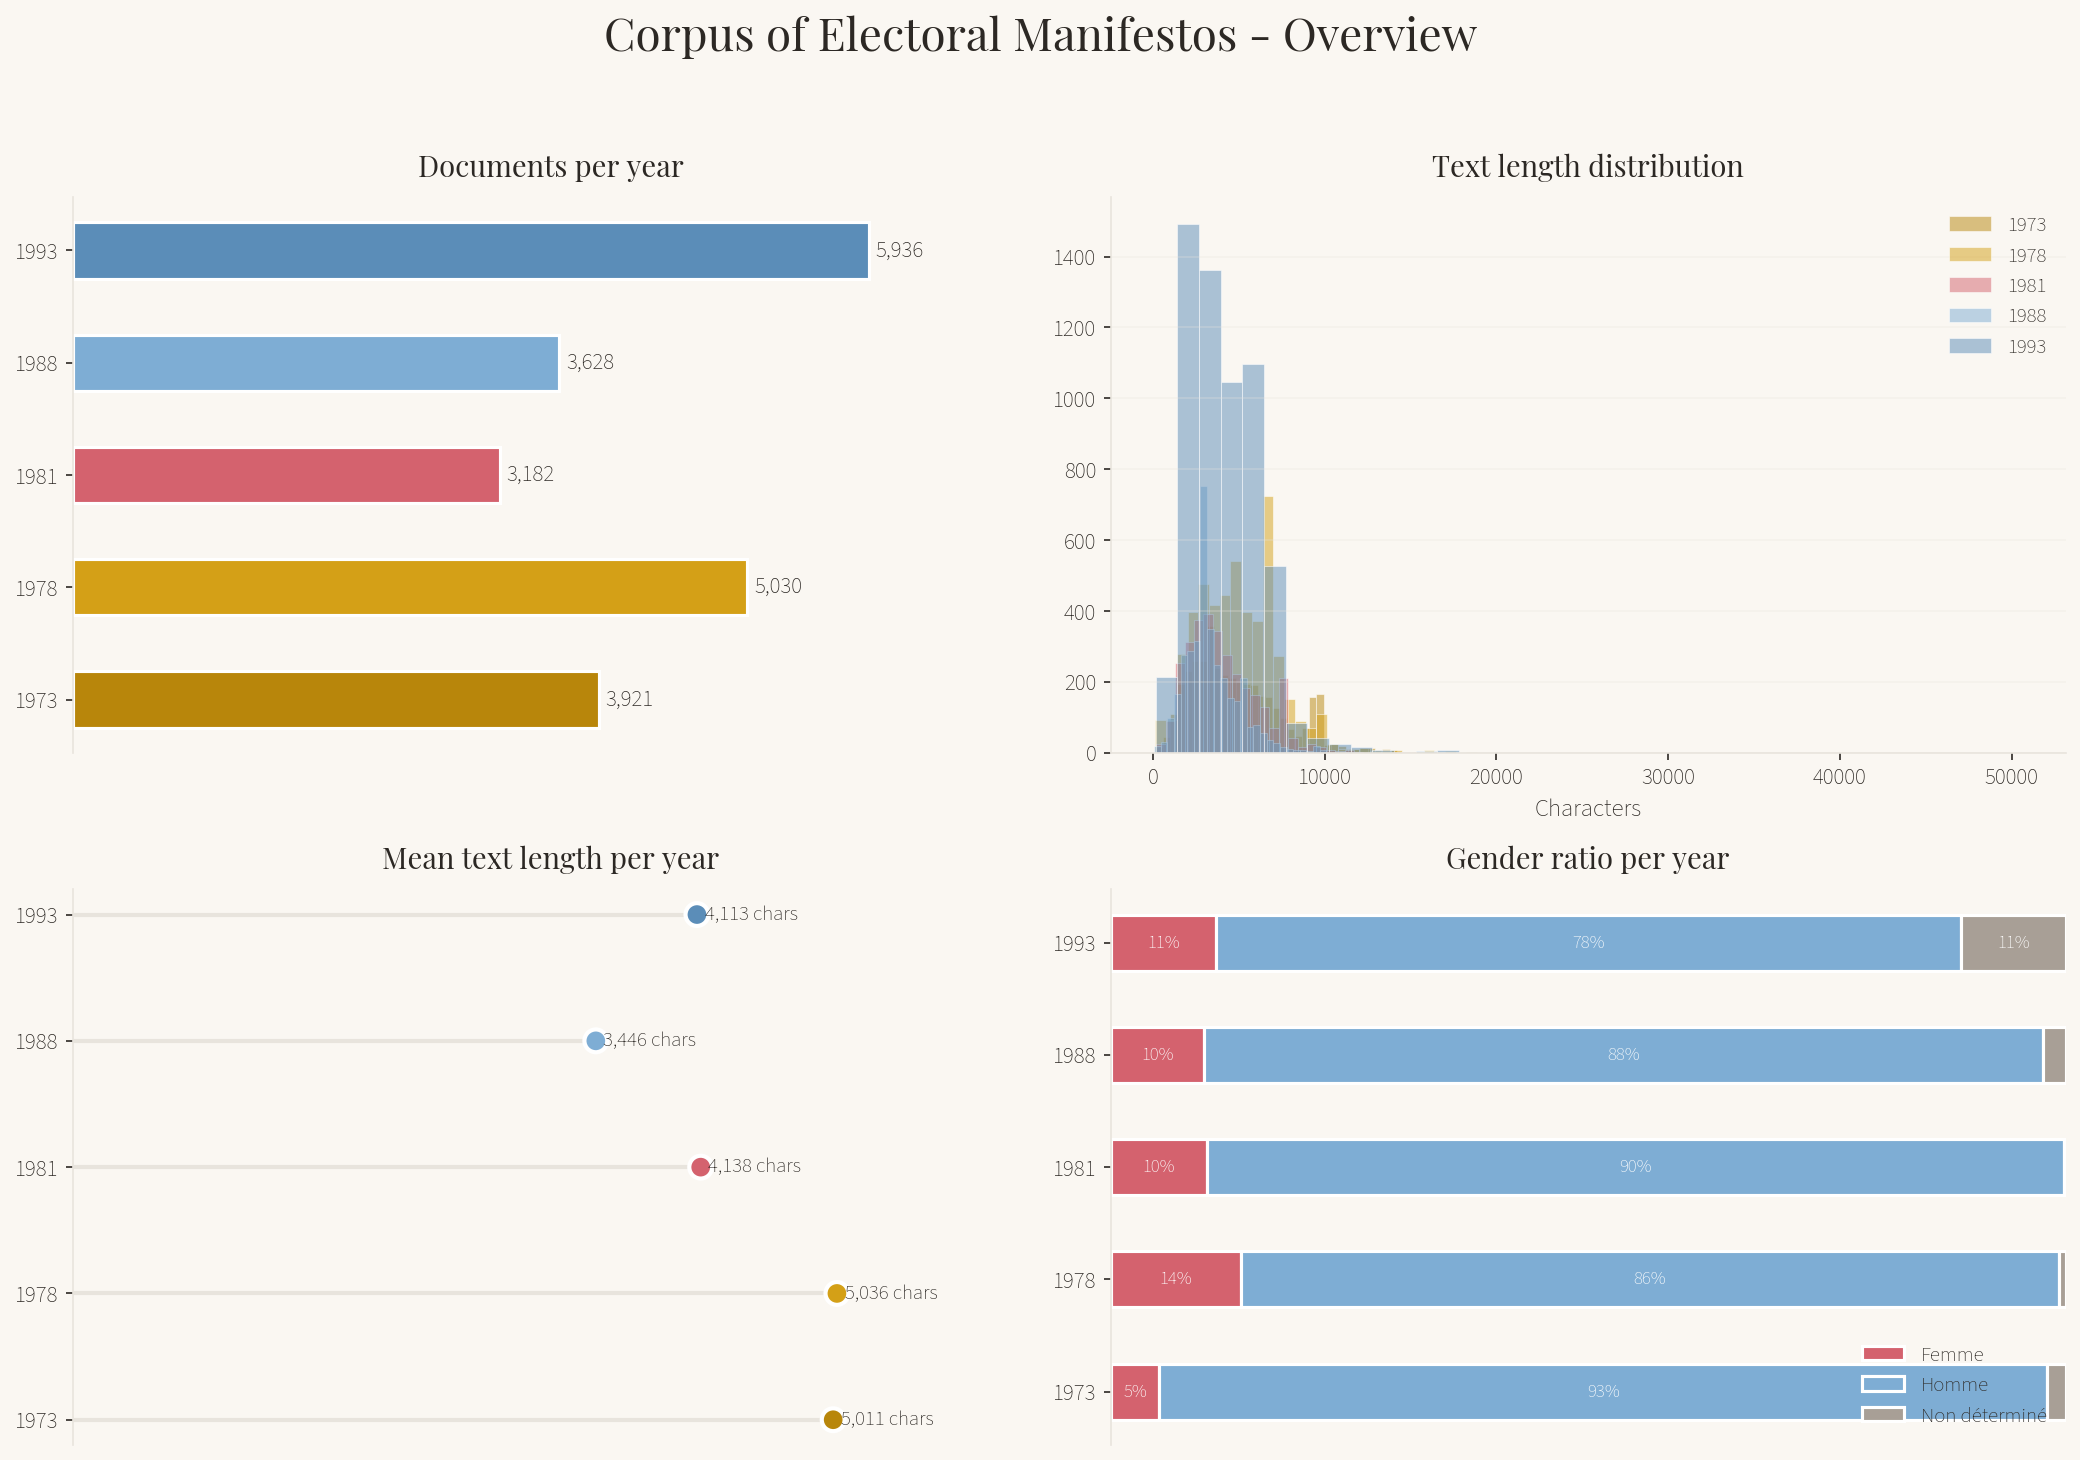

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Corpus of Electoral Manifestos - Overview",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

# Documents per year
ax = axes[0, 0]
year_counts = df['year'].value_counts().sort_index()
bars = ax.barh(year_counts.index, year_counts.values, height=0.5,
               color=[YEAR_COLORS.get(y, '#A89F96') for y in year_counts.index],
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, year_counts.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11, fontweight='bold', color=TEXT_COLOR)
ax.set_title("Documents per year", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlim(0, year_counts.max() * 1.2)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

# Text length distribution
ax = axes[0, 1]
for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]['text_length']
    ax.hist(subset, bins=40, alpha=0.5, label=year,
            color=YEAR_COLORS.get(year, '#A89F96'), edgecolor='white', linewidth=0.5)
ax.set_title("Text length distribution", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlabel("Characters")
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Mean text length (lollipop)
ax = axes[1, 0]
mean_lengths = df.groupby('year')['text_length'].mean().sort_index()
ax.hlines(mean_lengths.index, 0, mean_lengths.values, color=GRID_COLOR, linewidth=2)
ax.scatter(mean_lengths.values, mean_lengths.index, s=120, zorder=3,
           color=[YEAR_COLORS.get(y, '#A89F96') for y in mean_lengths.index],
           edgecolors='white', linewidth=2)
for y, val in zip(mean_lengths.index, mean_lengths.values):
    ax.text(val + 50, y, f'{val:,.0f} chars', va='center', fontsize=10, color=TEXT_COLOR)
ax.set_title("Mean text length per year", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlim(0, mean_lengths.max() * 1.25)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

# Gender ratio
ax = axes[1, 1]
ct = pd.crosstab(df['year'], df['titulaire-sexe'], normalize='index') * 100
ct_sorted = ct.sort_index()
colors_sexe = {'homme': '#7EADD4', 'femme': ACCENT_COLOR}
col_names = ct_sorted.columns.tolist()
bottom = np.zeros(len(ct_sorted))
for col in col_names:
    color = colors_sexe.get(col, '#A89F96')
    ax.barh(ct_sorted.index, ct_sorted[col], left=bottom, height=0.5,
            label=col.capitalize(), color=color, edgecolor='white', linewidth=1.5)
    for i, (val, b) in enumerate(zip(ct_sorted[col], bottom)):
        if val > 5:
            ax.text(b + val/2, ct_sorted.index[i], f'{val:.0f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    bottom += ct_sorted[col].values
ax.set_title("Gender ratio per year", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlim(0, 100)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.legend(frameon=False, loc='lower right', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("../data/exploration_base.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

The corpus shows a clear increase in candidacies between 1973 and 1993. Text lengths are fairly consistent across years (~3,500–4,100 characters). The gender imbalance is persistent but slowly improving: the share of female candidates grows modestly over the five elections.

### 6.2 Dominant vocabulary per year

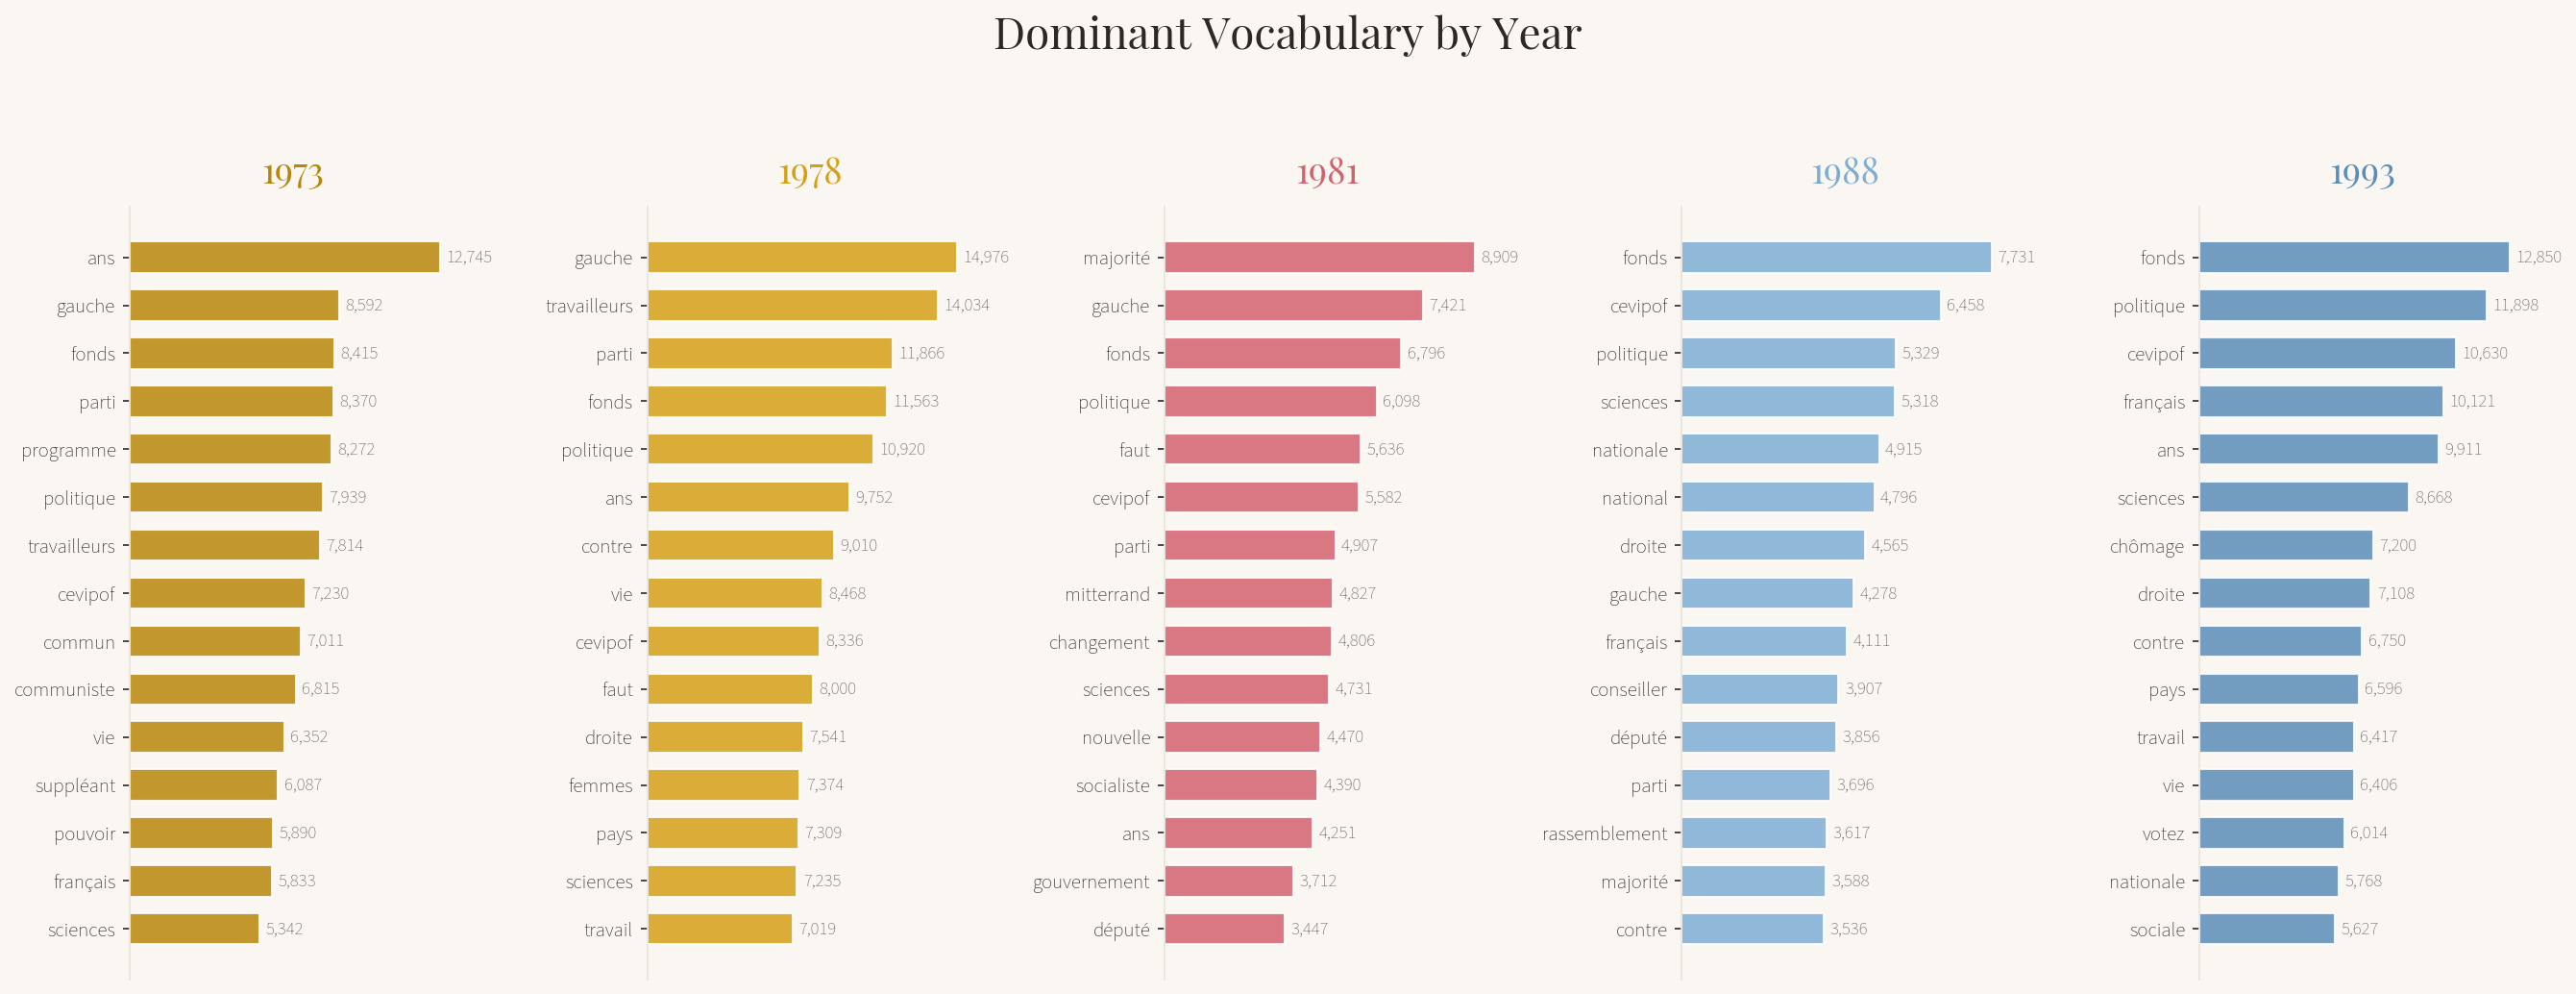

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(18, 7))
fig.suptitle("Dominant Vocabulary by Year",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.98, color=TEXT_COLOR)

for i, year in enumerate(sorted(df['year'].unique())):
    ax = axes[i]
    top = get_top_words(df[df['year'] == year], 15)
    words, counts = zip(*top)
    max_count = max(counts)
    color = YEAR_COLORS.get(year, '#A89F96')
    bars = ax.barh(range(len(words)), counts, height=0.65,
                   color=color, alpha=0.85, edgecolor='white', linewidth=1)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10, fontfamily=FONT_BODY)
    ax.invert_yaxis()
    ax.set_title(year, fontfamily=FONT_TITLE, fontsize=18, fontweight='bold',
                 color=color, pad=12)
    ax.xaxis.set_visible(False)
    ax.spines['bottom'].set_visible(False)
    for bar, val in zip(bars, counts):
        ax.text(val + max_count * 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9, color=TEXT_COLOR, alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/top_mots_par_annee.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

The most frequent words are largely stable across elections: *politique*, *pays*, *travail*, *vie* dominate throughout. Shifts are visible in party-specific vocabulary (e.g., *changement* in 1981, *chômage* rising in 1993), which we will investigate further through topic modeling in Notebook 03.

---

## 7. Political Landscape

### 7.1 Party family distribution

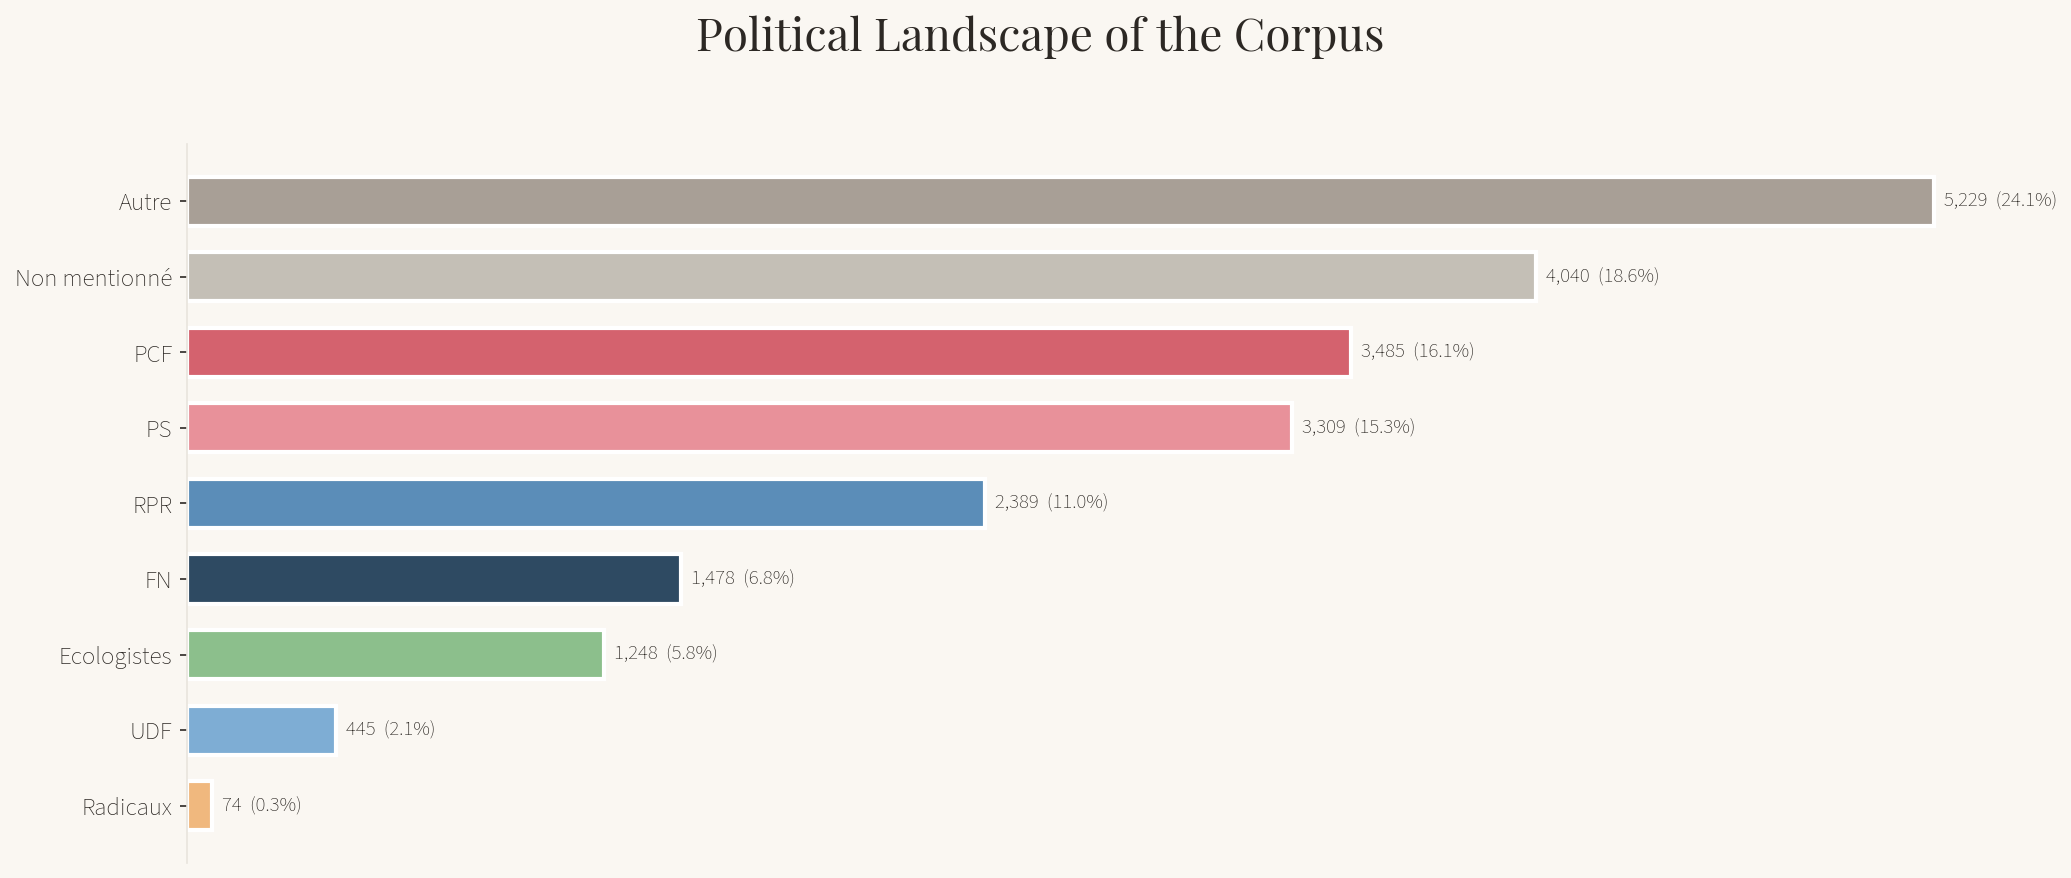

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Political Landscape of the Corpus",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

party_counts = df['parti_famille'].value_counts()
parties = party_counts.index.tolist()
counts = party_counts.values
colors = [PARTY_COLORS.get(p, '#A89F96') for p in parties]
bars = ax.barh(range(len(parties)), counts, height=0.65,
               color=colors, edgecolor='white', linewidth=2)
ax.set_yticks(range(len(parties)))
ax.set_yticklabels(parties, fontsize=12, fontfamily=FONT_BODY, fontweight='bold')
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar, val, party in zip(bars, counts, parties):
    pct = val / len(df) * 100
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=10, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/paysage_politique.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 7.2 Party evolution over time

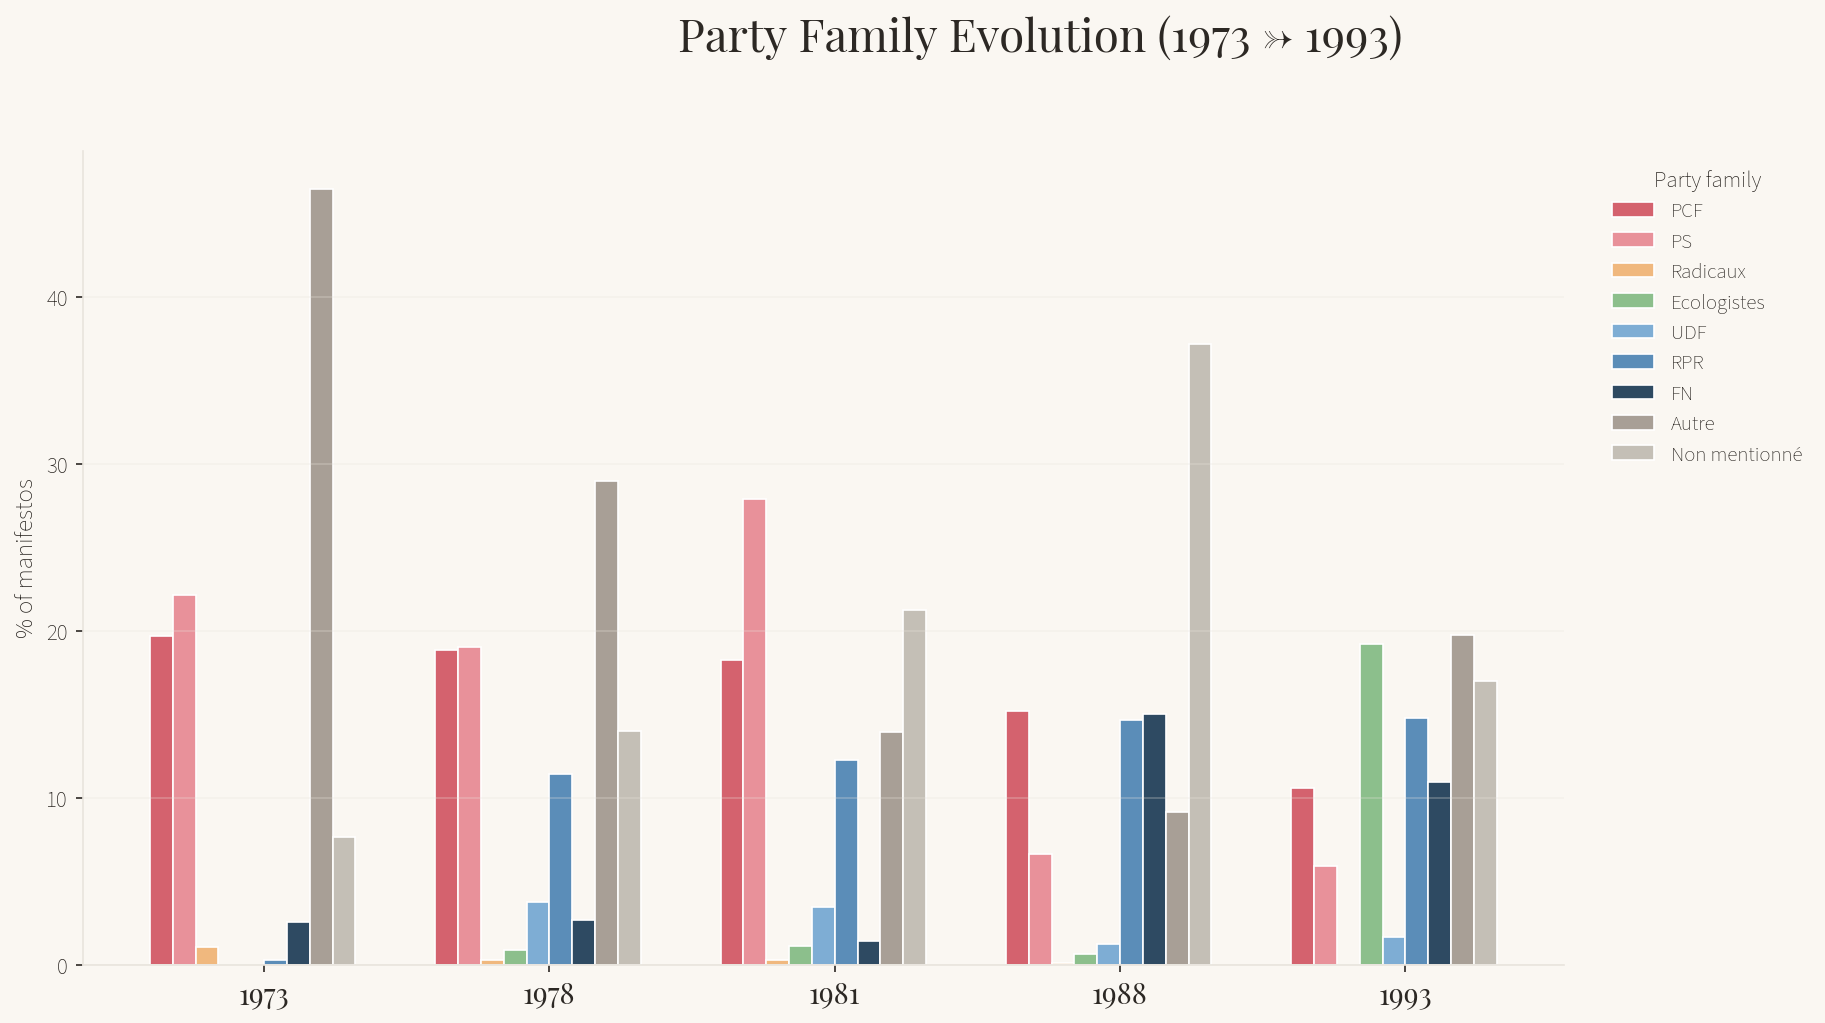

In [18]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Party Family Evolution (1973 → 1993)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

ct = pd.crosstab(df['year'], df['parti_famille'], normalize='index') * 100
ct = ct.sort_index()
main_parties = ['PCF', 'PS', 'Radicaux', 'Ecologistes', 'UDF', 'RPR', 'FN', 'Autre', 'Non mentionné']
main_parties = [p for p in main_parties if p in ct.columns]

x = np.arange(len(ct.index))
width = 0.08
n_parties = len(main_parties)

for i, party in enumerate(main_parties):
    offset = (i - n_parties/2) * width
    color = PARTY_COLORS.get(party, '#A89F96')
    ax.bar(x + offset, ct[party], width=width, label=party,
           color=color, edgecolor='white', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(ct.index, fontsize=14, fontfamily=FONT_TITLE, fontweight='bold')
ax.set_ylabel("% of manifestos", fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False,
          fontsize=10, title="Party family",
          title_fontproperties={'weight': 'bold', 'size': 11})

plt.tight_layout(rect=[0, 0, 0.88, 0.93])
plt.savefig("../data/evolution_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

Key trends visible here: the **PCF** share shrinks from 1973 to 1993, while the **FN** and **Ecologistes** surge in 1993. The RPR+UDF right-wing bloc remains relatively stable, and the share of unlabeled candidates (`Non mentionné`) decreases over time as party branding becomes more systematic.

---

## 8. Socio-Professional Profile of Candidates

### 8.1 Raw professions (top 15 exact strings)

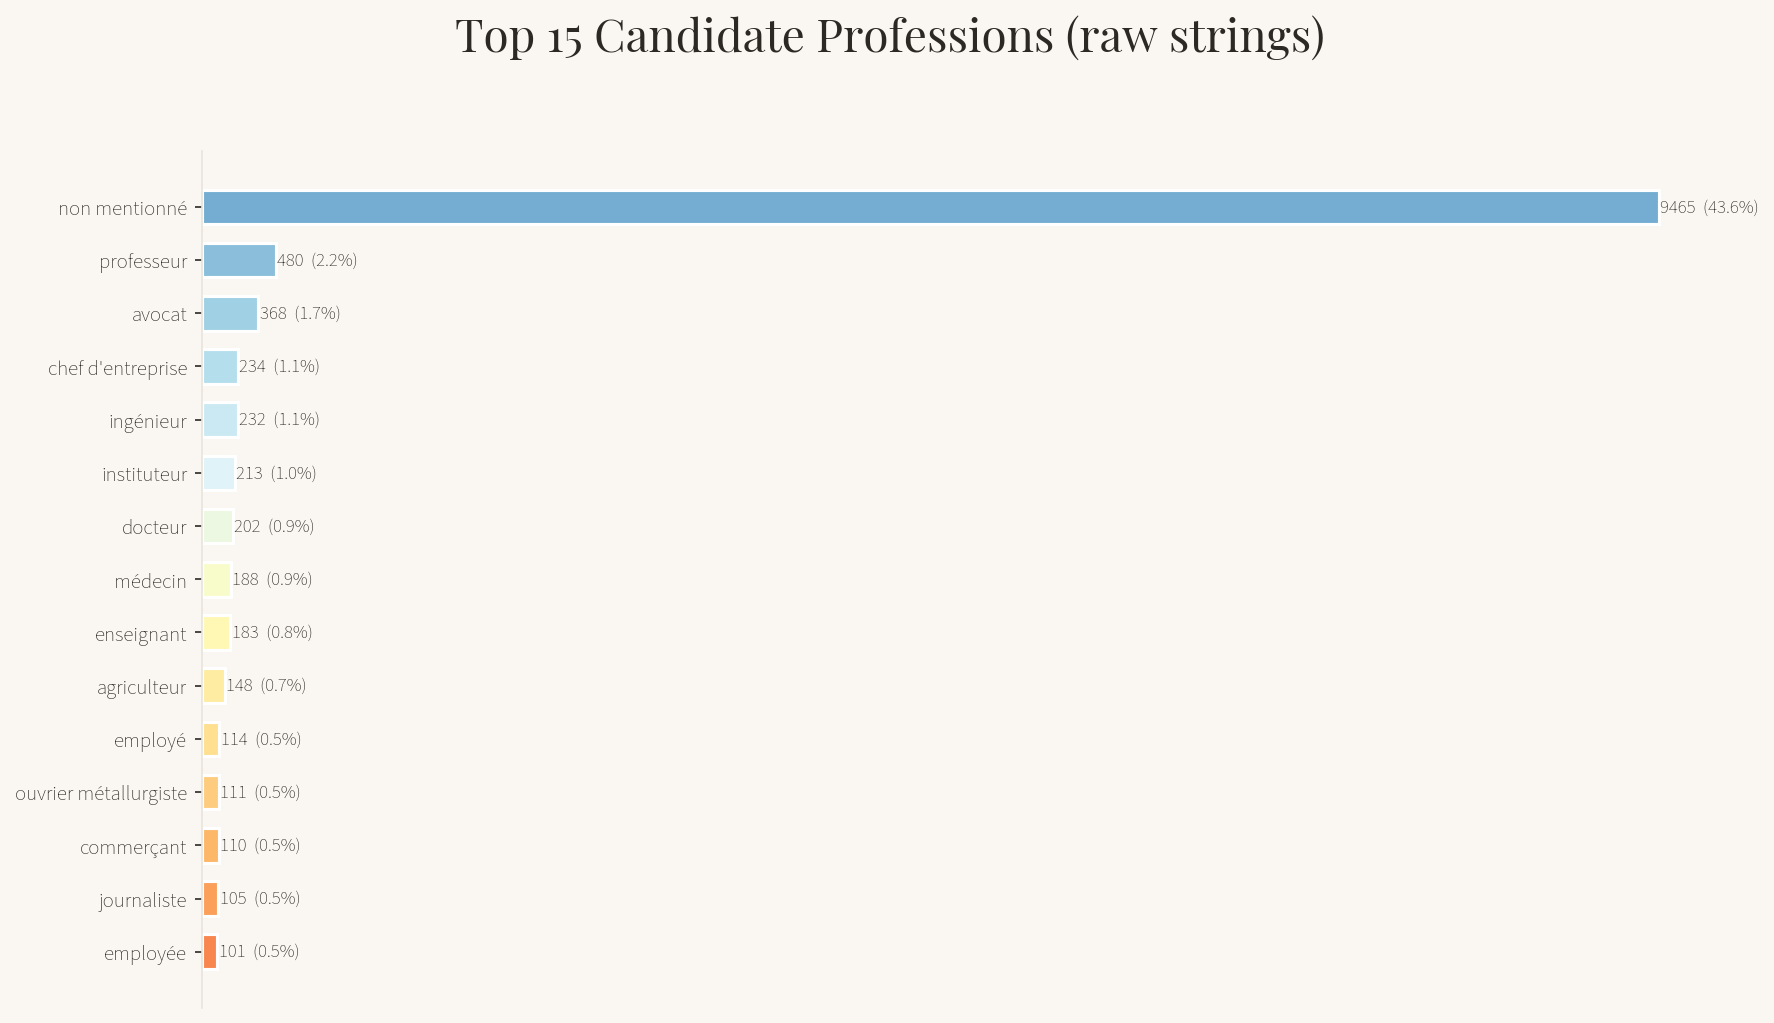

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Top 15 Candidate Professions (raw strings)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

prof_counts = df['titulaire-profession'].value_counts().head(15)
cmap = plt.cm.RdYlBu_r
colors_gradient = [cmap(0.2 + 0.6 * i / len(prof_counts)) for i in range(len(prof_counts))]

bars = ax.barh(range(len(prof_counts)), prof_counts.values, height=0.65,
               color=colors_gradient, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(prof_counts)))
ax.set_yticklabels(prof_counts.index, fontsize=10, fontfamily=FONT_BODY)
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar, val in zip(bars, prof_counts.values):
    pct = val / len(df) * 100
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            f'{val}  ({pct:.1f}%)', va='center', fontsize=9, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/professions_candidats.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 8.2 Professions by keyword

Since raw profession strings are highly fragmented (2,000+ unique values), a keyword-based aggregation gives a more interpretable picture.

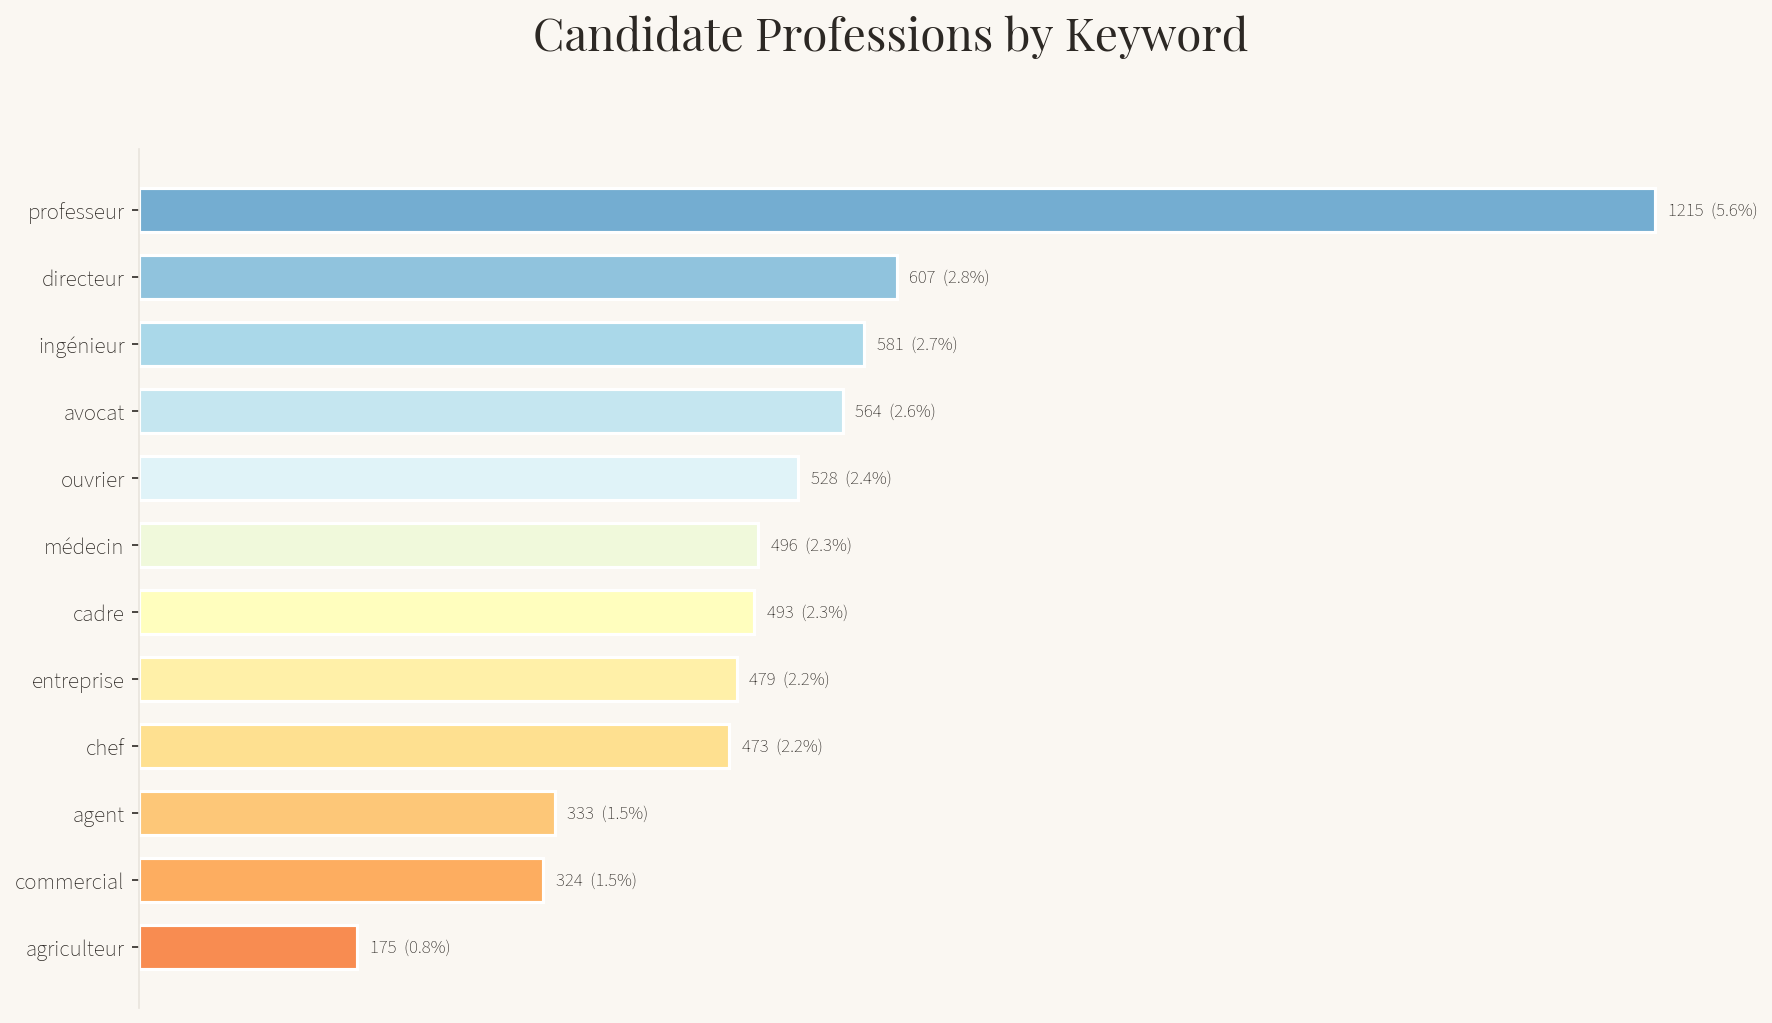

In [20]:
profession_keywords = [
    'professeur', 'directeur', 'ingénieur', 'cadre', 'chef',
    'entreprise', 'médecin', 'agent', 'avocat', 'agriculteur',
    'ouvrier', 'commercial'
]

prof_kw_counts = {}
for keyword in profession_keywords:
    mask = df['titulaire-profession'].str.contains(keyword, case=False, na=False)
    prof_kw_counts[keyword] = mask.sum()

prof_series = pd.Series(prof_kw_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Candidate Professions by Keyword",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

cmap = plt.cm.RdYlBu_r
colors_gradient = [cmap(0.2 + 0.6 * i / len(prof_series)) for i in range(len(prof_series))]
bars = ax.barh(range(len(prof_series)), prof_series.values, height=0.65,
               color=colors_gradient, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(prof_series)))
ax.set_yticklabels(prof_series.index, fontsize=11, fontfamily=FONT_BODY)
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar, val in zip(bars, prof_series.values):
    pct = val / len(df) * 100
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            f'{val}  ({pct:.1f}%)', va='center', fontsize=9, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/professions_mots_cles.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 8.3 BERT-classified PCS categories

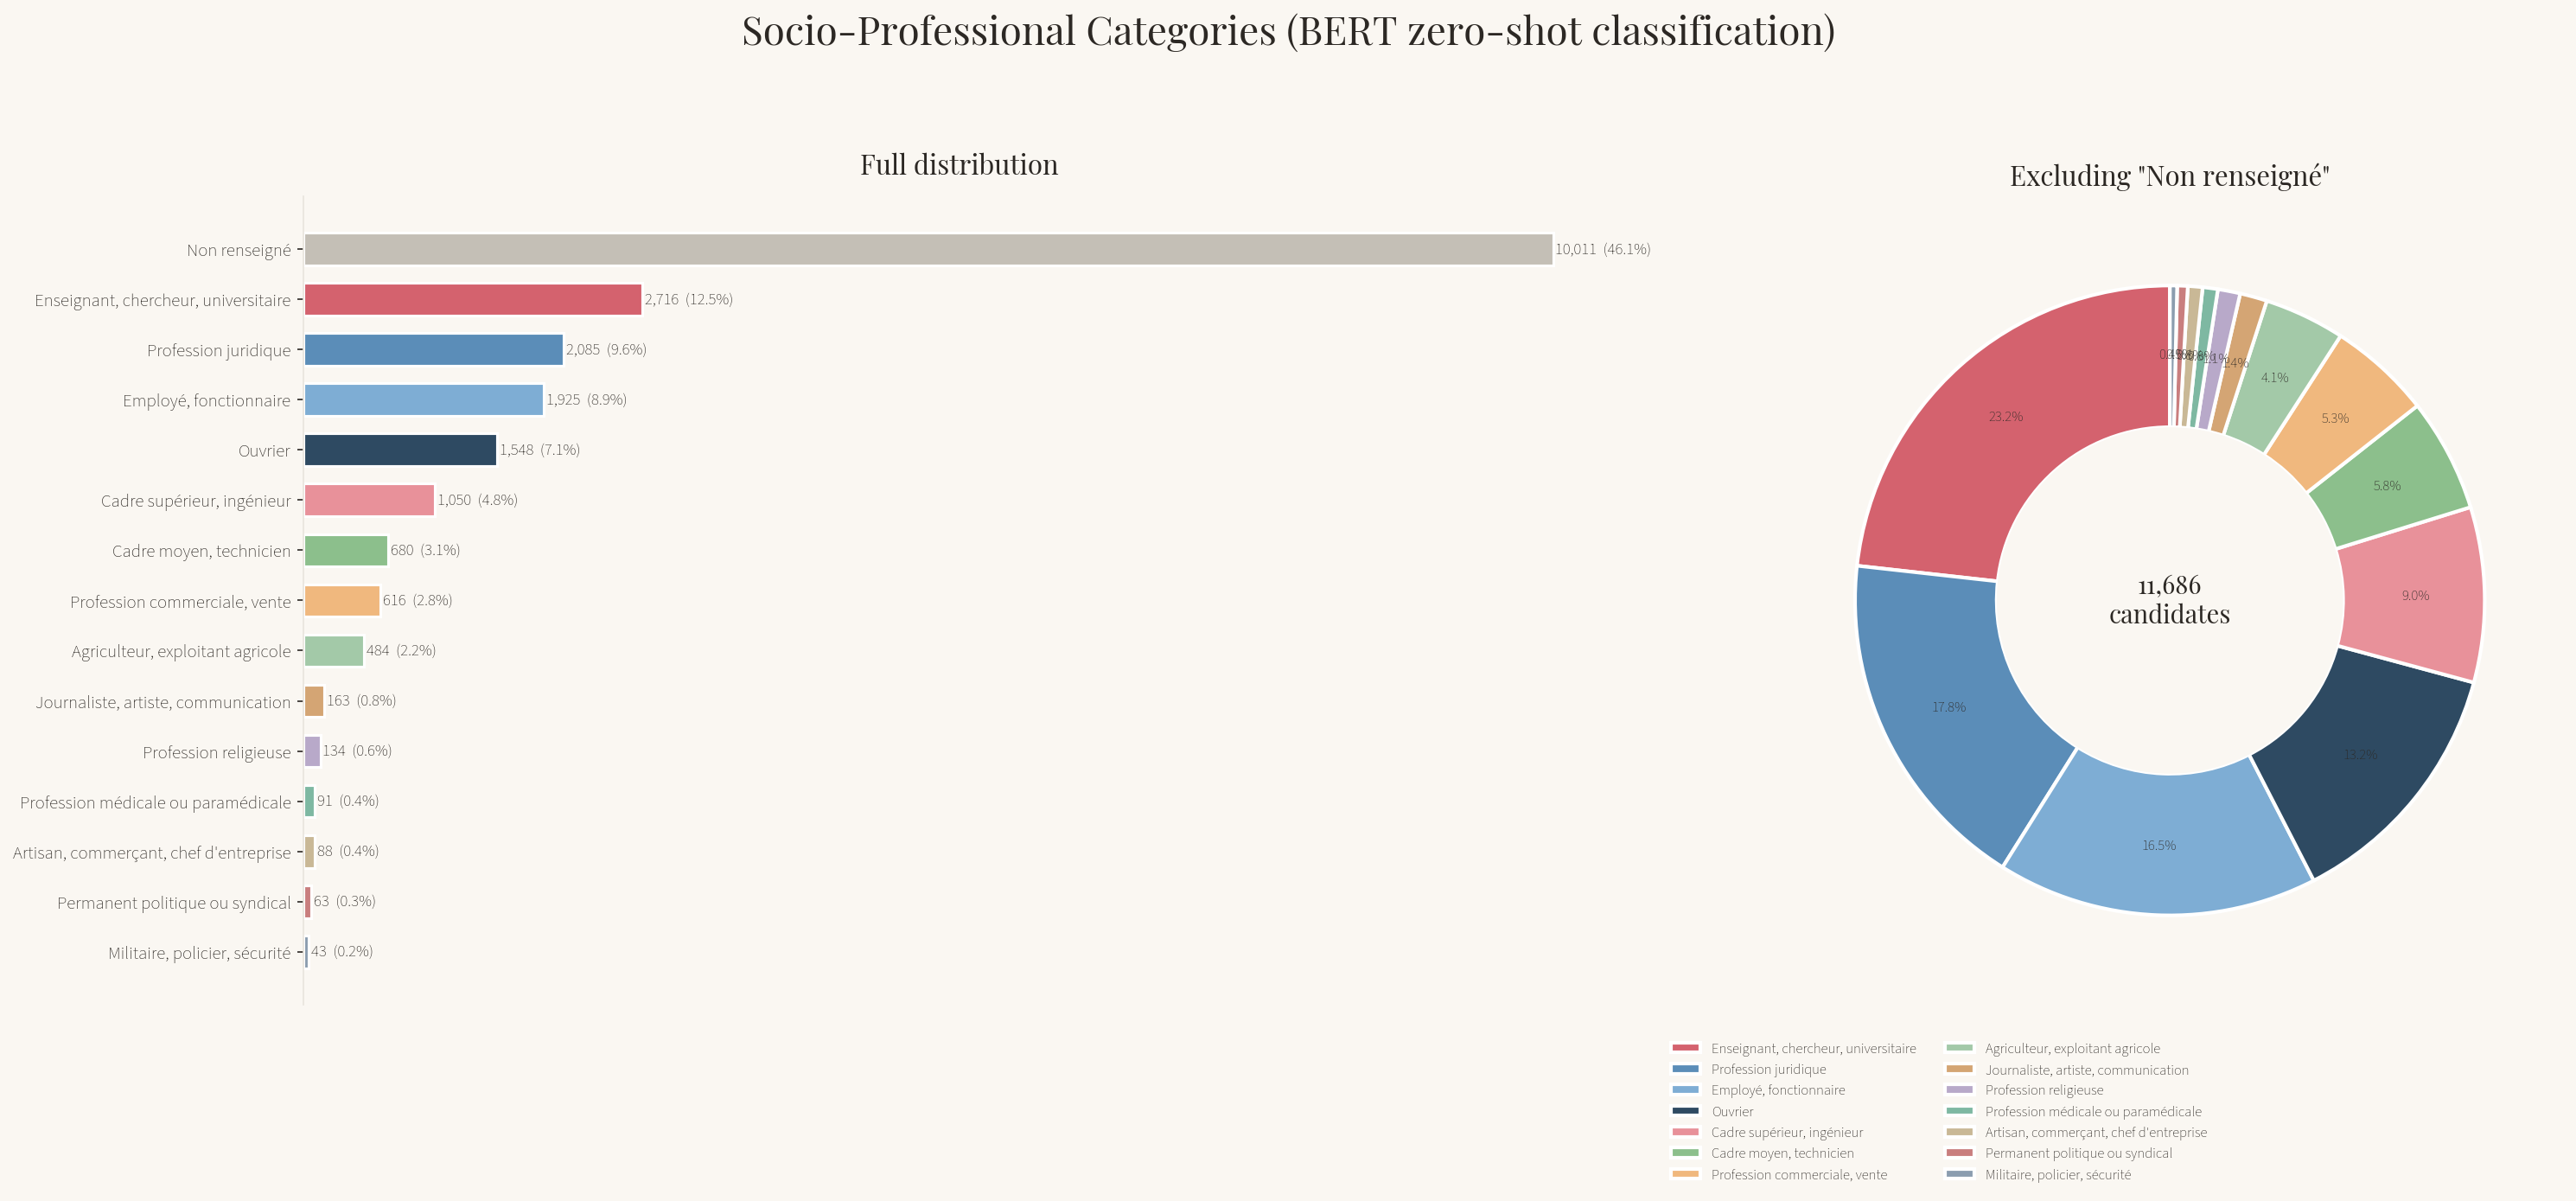

In [21]:
pcs_counts = df['profession_pcs'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(20, 9), gridspec_kw={'width_ratios': [2, 1.2]})
fig.suptitle("Socio-Professional Categories (BERT zero-shot classification)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.98, color=TEXT_COLOR)

# Left: horizontal bars
ax = axes[0]
categories = pcs_counts.index.tolist()
values = pcs_counts.values
colors = [PCS_COLORS.get(c, '#A89F96') for c in categories]
bars = ax.barh(range(len(categories)), values, height=0.65,
               color=colors, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories, fontsize=10, fontfamily=FONT_BODY)
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)
for bar, val in zip(bars, values):
    pct = val / len(df) * 100
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=9, color=TEXT_COLOR)
ax.set_title("Full distribution", fontfamily=FONT_TITLE, fontsize=15, pad=12)

# Right: donut chart (excluding "Non renseigné")
ax2 = axes[1]
pcs_filled = pcs_counts.drop('Non renseigné', errors='ignore')
labels = pcs_filled.index.tolist()
sizes = pcs_filled.values
colors_donut = [PCS_COLORS.get(c, '#A89F96') for c in labels]
wedges, texts, autotexts = ax2.pie(
    sizes, labels=None, autopct='%1.1f%%', startangle=90,
    colors=colors_donut, pctdistance=0.78,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2))
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color(TEXT_COLOR)
    autotext.set_fontweight('bold')
ax2.legend(wedges, labels, loc='center left', bbox_to_anchor=(-0.15, -0.15),
           fontsize=8, frameon=False, ncol=2)
ax2.set_title('Excluding "Non renseigné"', fontfamily=FONT_TITLE, fontsize=15, pad=12)
centre_circle = plt.Circle((0, 0), 0.55, fc=BG_COLOR)
ax2.add_artist(centre_circle)
n_filled = pcs_filled.sum()
ax2.text(0, 0, f'{n_filled:,}\ncandidates', ha='center', va='center',
         fontsize=14, fontweight='bold', fontfamily=FONT_TITLE, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig("../data/professions_pcs_bert.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

The BERT-based classification reveals a strong over-representation of **teachers and researchers** (~22% of classified candidates), followed by **legal professionals**, **employees/civil servants**, and **blue-collar workers**. This is consistent with the known sociological profile of French political candidates, where the public sector is heavily represented.

---

## 9. Advanced Cross-Analyses

This section combines multiple metadata dimensions to reveal structural patterns in the corpus.

### 9.1 Socio-professional profile by party (heatmap)

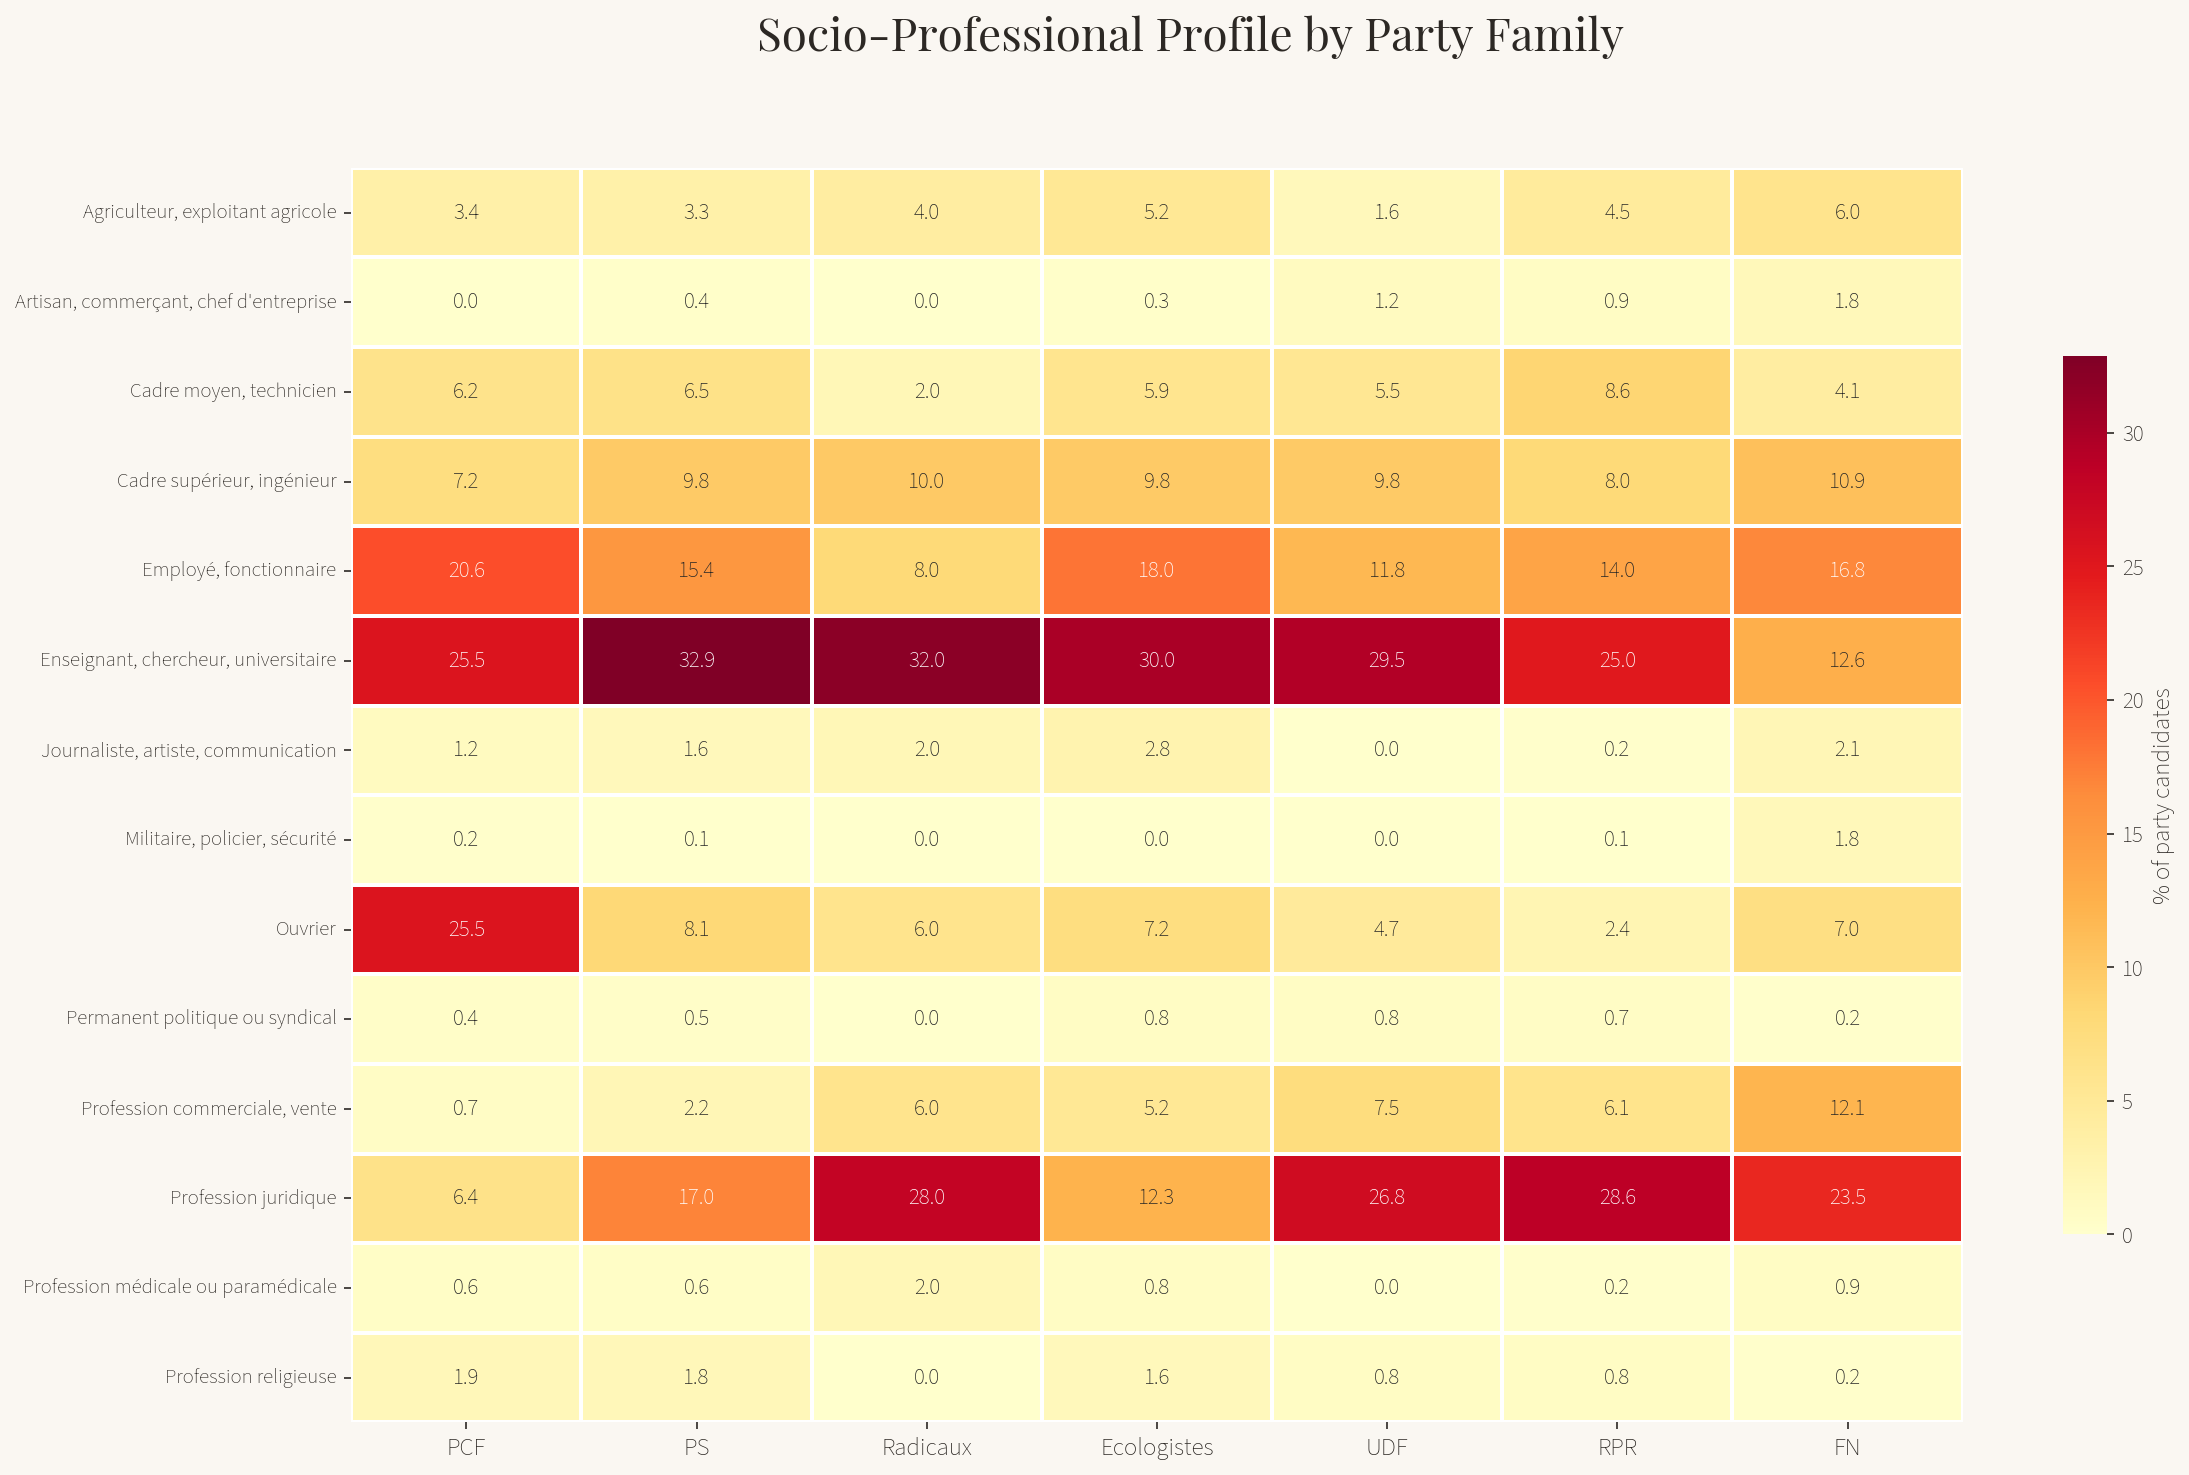

In [22]:
fig, ax = plt.subplots(figsize=(16, 10))
fig.suptitle("Socio-Professional Profile by Party Family",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.98)

main_parties = ['PCF', 'PS', 'Radicaux', 'Ecologistes', 'UDF', 'RPR', 'FN']
df_cross = df[df['parti_famille'].isin(main_parties) & (df['profession_pcs'] != 'Non renseigné')]
ct = pd.crosstab(df_cross['profession_pcs'], df_cross['parti_famille'], normalize='columns') * 100
ct = ct[main_parties]

sns.heatmap(ct, cmap='YlOrRd', annot=True, fmt='.1f', linewidths=1,
            linecolor='white', ax=ax, cbar_kws={'label': '% of party candidates', 'shrink': 0.7})
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=12, rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("../data/heatmap_pcs_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

This heatmap reveals strong profession–party correlations. For instance, the PCF draws heavily from **blue-collar workers**, while the PS and RPR recruit predominantly from **teachers** and **senior executives**. The FN shows a more diverse professional base, consistent with its catch-all populist positioning.

### 9.2 Feminization trends by party

/tmp/ipykernel_5126/1264989485.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fem_rate = df_sex.groupby(['year', 'parti_famille']).apply(


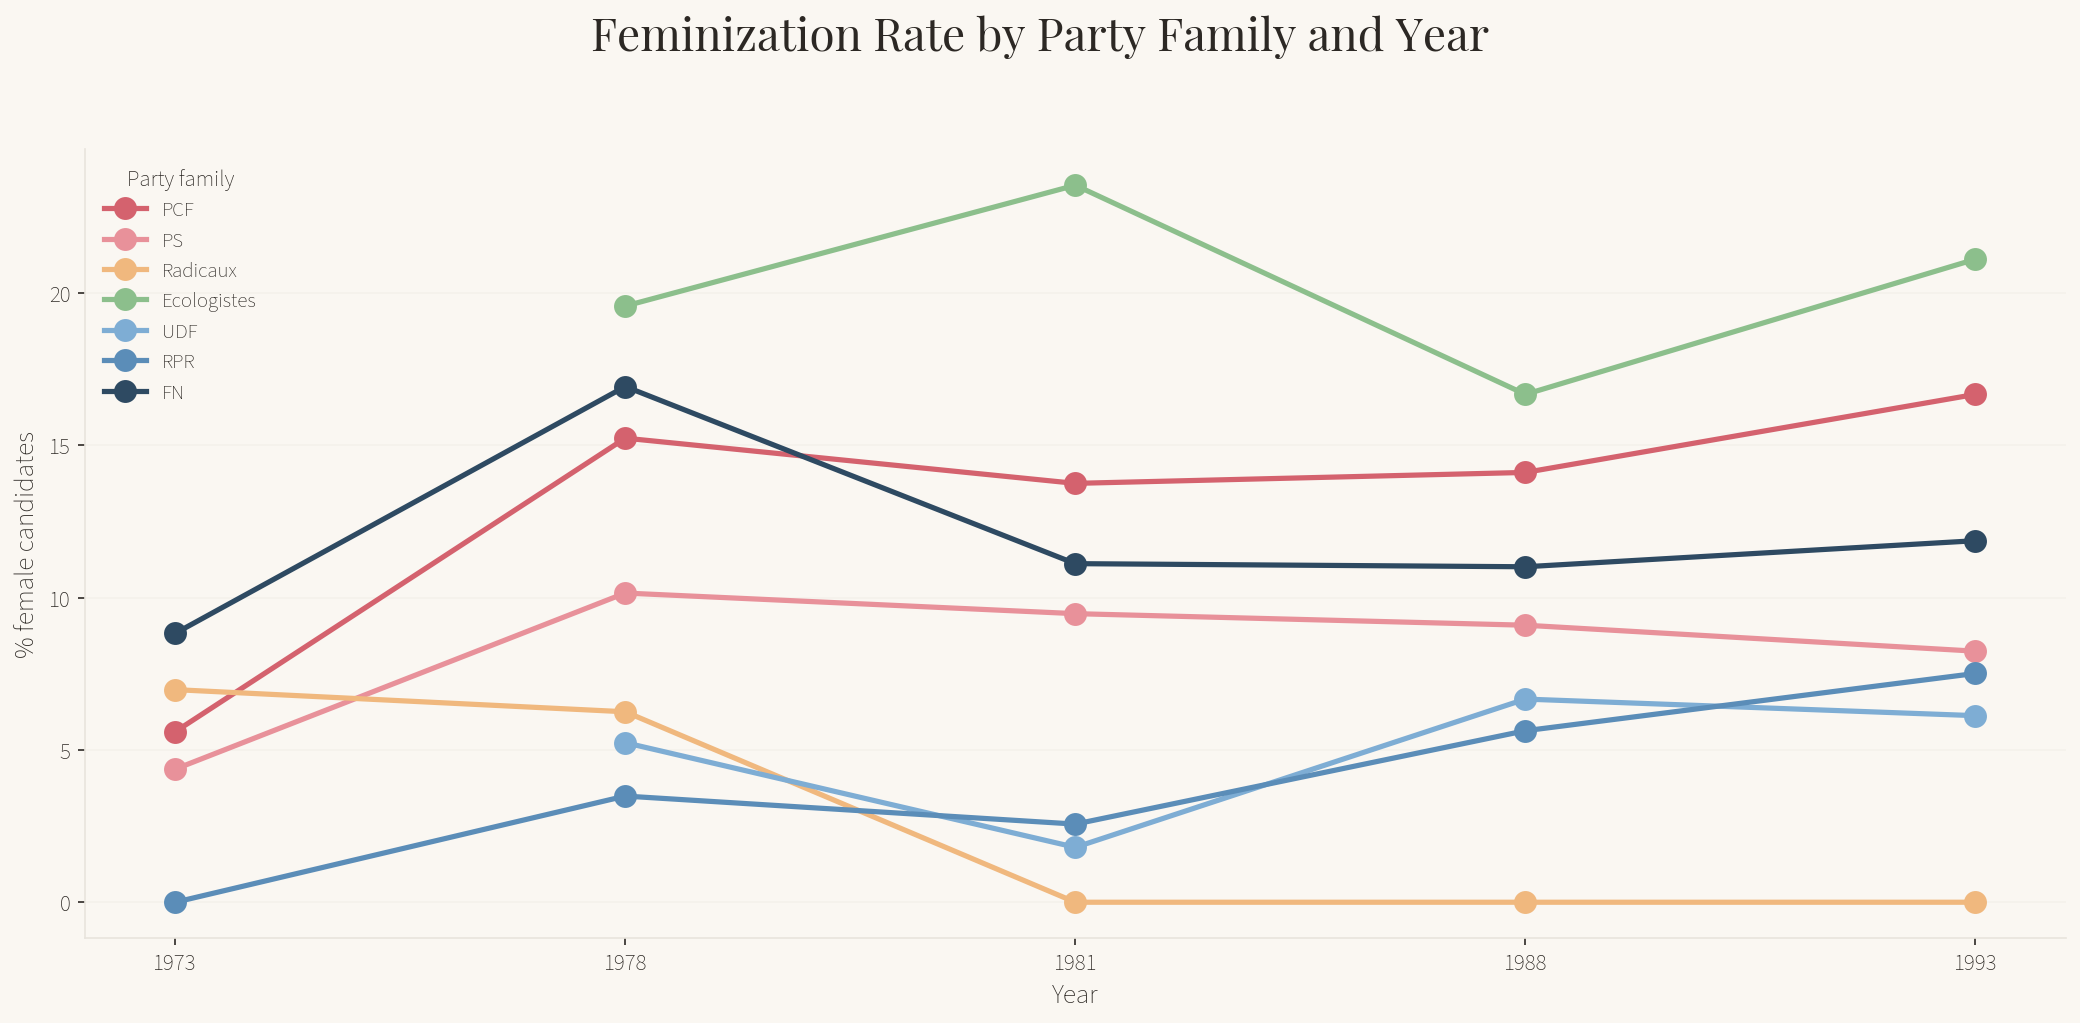

In [23]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Feminization Rate by Party Family and Year",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

df_sex = df[df['parti_famille'].isin(main_parties) & (df['titulaire-sexe'] != 'non déterminé')]
fem_rate = df_sex.groupby(['year', 'parti_famille']).apply(
    lambda x: (x['titulaire-sexe'] == 'femme').mean() * 100
).reset_index(name='taux_femmes')

for party in main_parties:
    data = fem_rate[fem_rate['parti_famille'] == party]
    ax.plot(data['year'], data['taux_femmes'], marker='o', markersize=10,
            linewidth=2.5, label=party, color=PARTY_COLORS.get(party, '#A89F96'))

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("% female candidates", fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False, fontsize=10, title="Party family",
          title_fontproperties={'weight': 'bold', 'size': 11})

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/feminisation_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 9.3 Age distribution by party (violin plot)

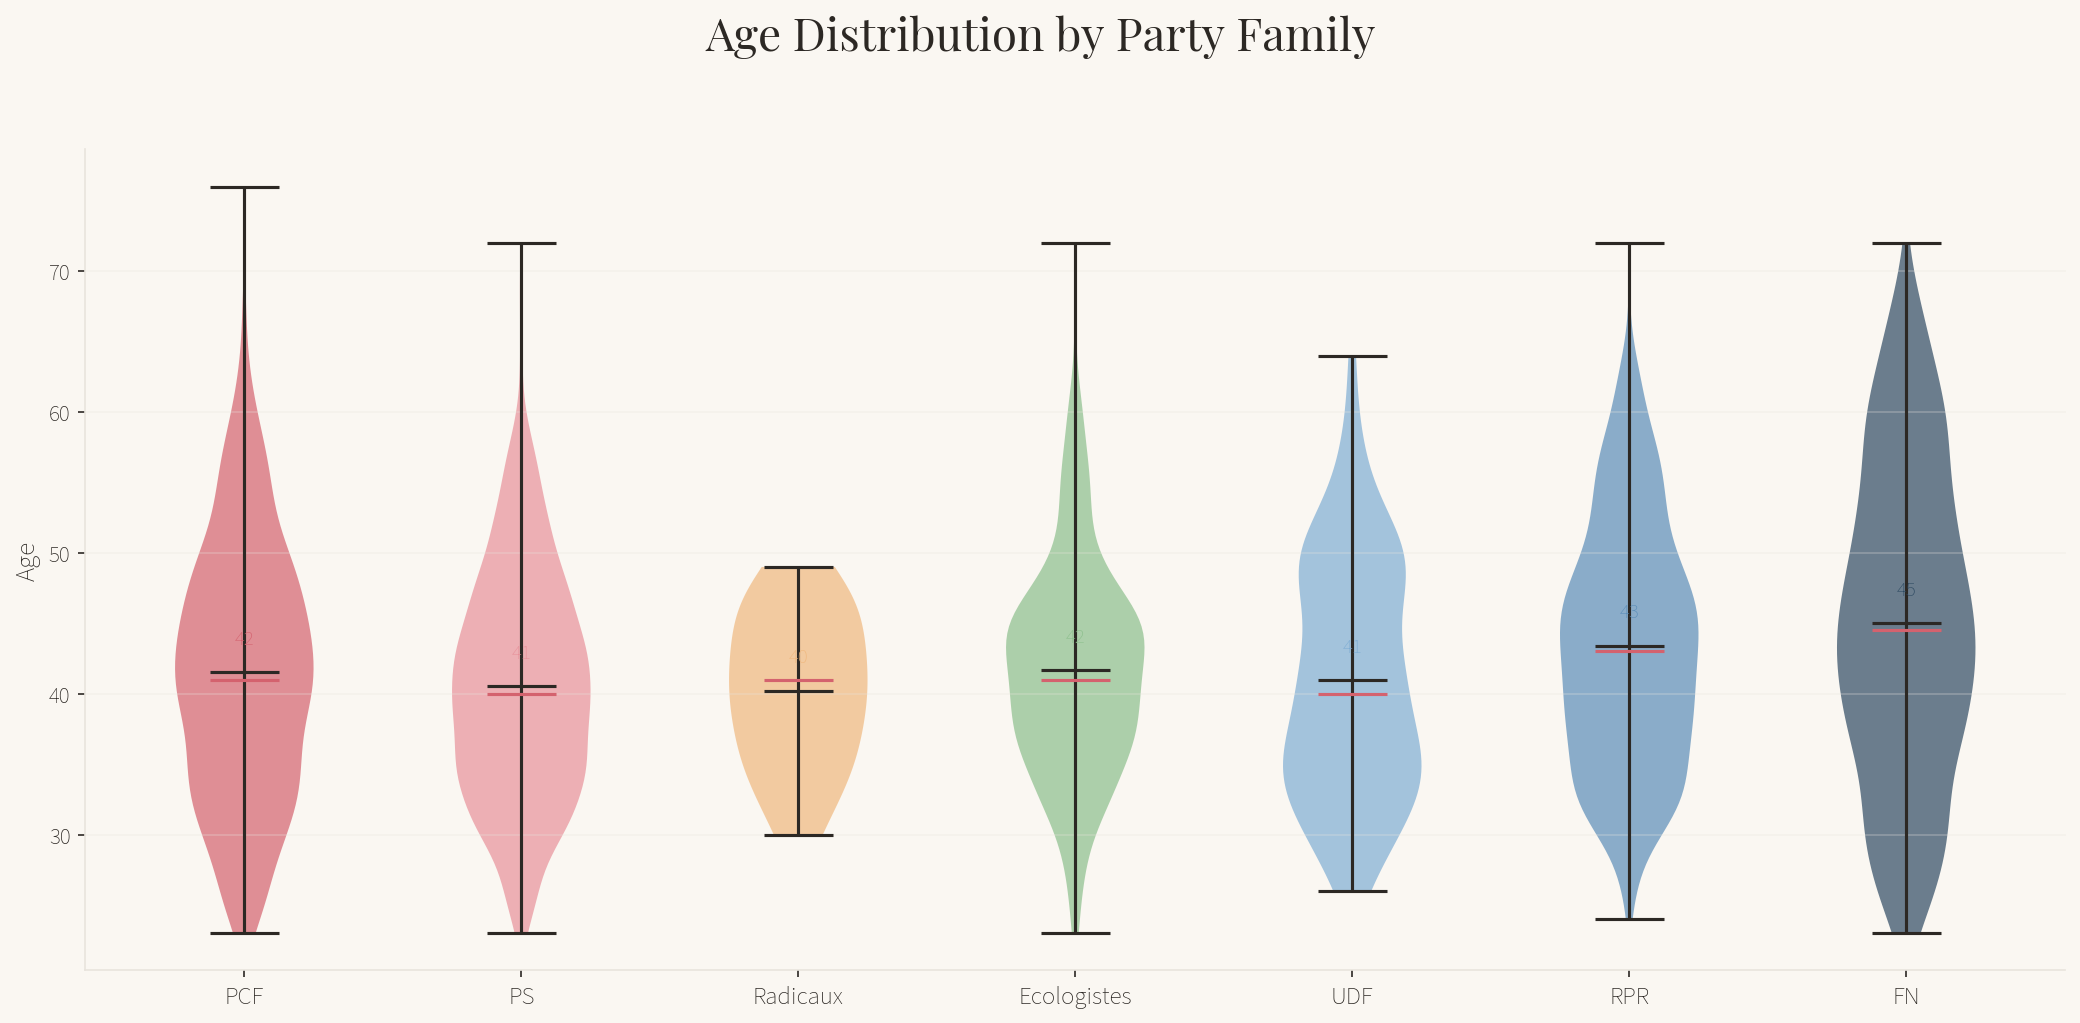

In [24]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Age Distribution by Party Family",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

df_age = df[df['parti_famille'].isin(main_parties)].copy()
df_age['age_num'] = pd.to_numeric(df_age['titulaire-age-calcule'], errors='coerce')
df_age = df_age.dropna(subset=['age_num'])
df_age = df_age[(df_age['age_num'] > 18) & (df_age['age_num'] < 100)]

order = [p for p in main_parties if p in df_age['parti_famille'].unique()]

parts = ax.violinplot(
    [df_age[df_age['parti_famille'] == p]['age_num'].values for p in order],
    positions=range(len(order)), showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PARTY_COLORS[order[i]])
    pc.set_alpha(0.7)

parts['cmeans'].set_color(TEXT_COLOR)
parts['cmedians'].set_color('#D4626E')
parts['cmins'].set_color(TEXT_COLOR)
parts['cmaxes'].set_color(TEXT_COLOR)
parts['cbars'].set_color(TEXT_COLOR)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, fontsize=12)
ax.set_ylabel("Age", fontsize=13)
ax.grid(axis='y', alpha=0.3)

for i, party in enumerate(order):
    mean_age = df_age[df_age['parti_famille'] == party]['age_num'].mean()
    ax.text(i, mean_age + 2, f'{mean_age:.0f}', ha='center', fontsize=10,
            fontweight='bold', color=PARTY_COLORS[party])

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/age_partis_violin.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 9.4 Geographic distribution (top 25 departments)

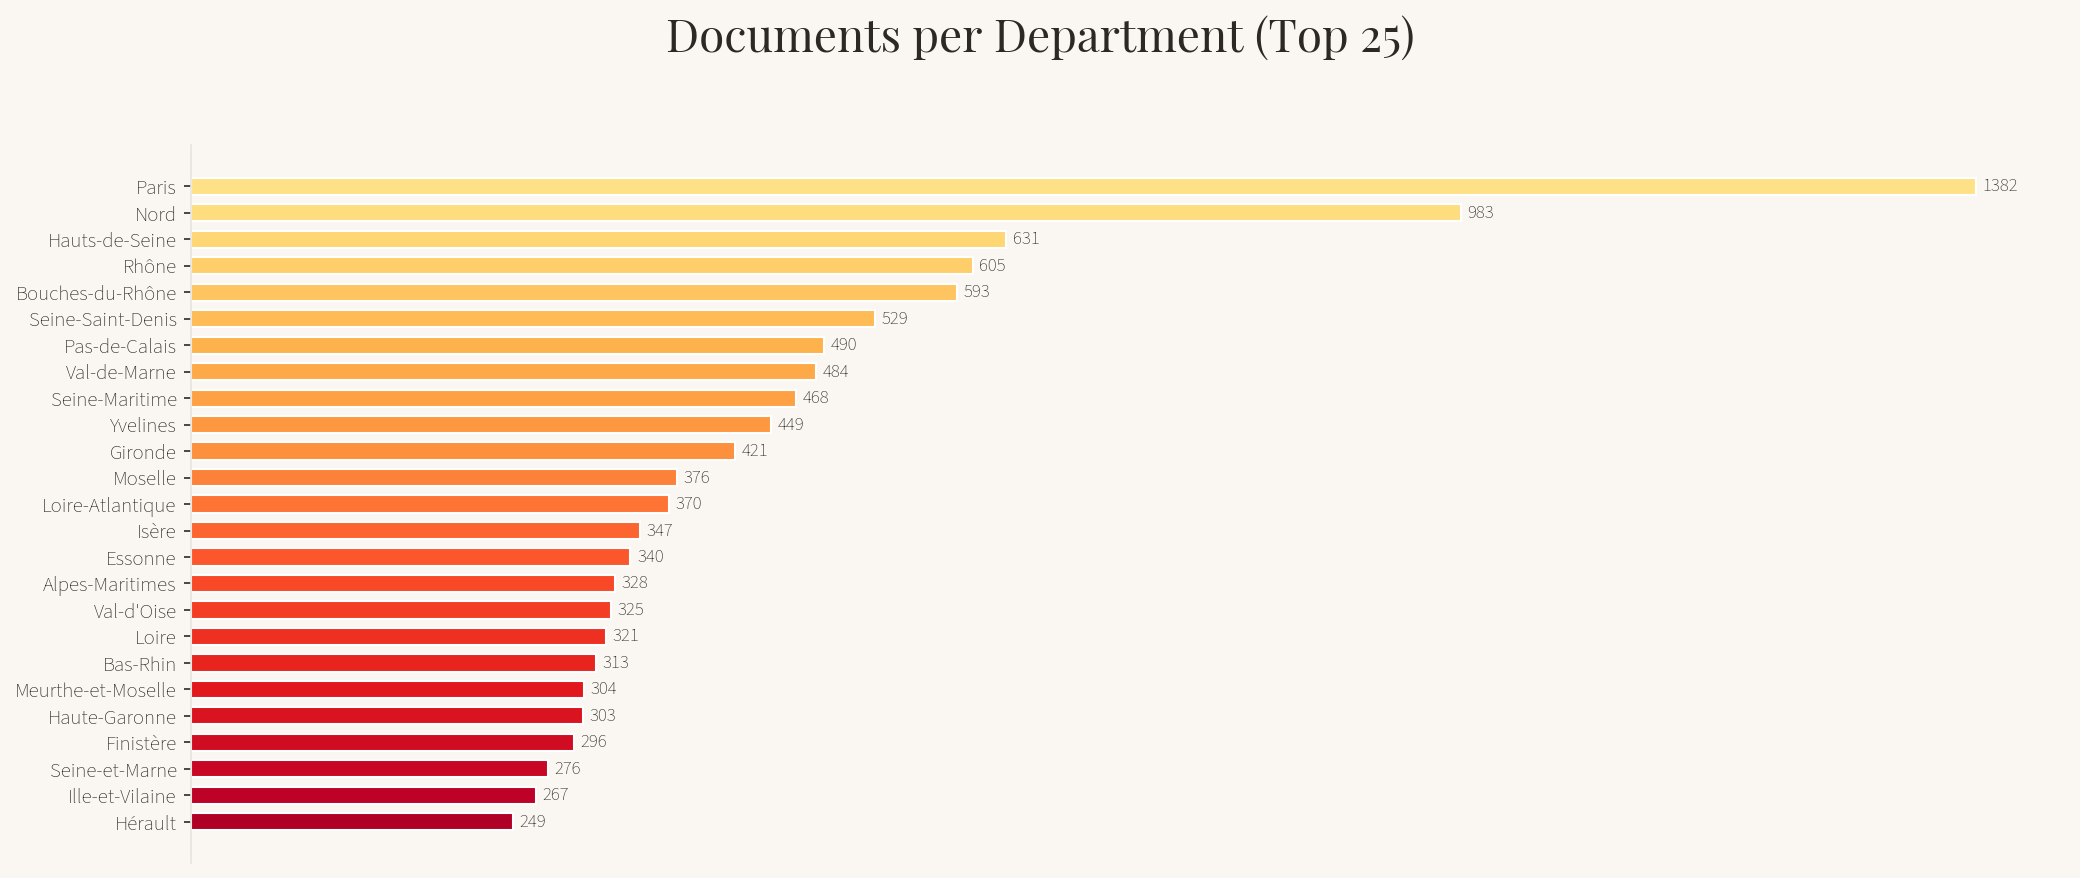

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Documents per Department (Top 25)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

dept_counts = df['departement-nom'].value_counts().head(25)
colors_dept = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(dept_counts)))

bars = ax.barh(range(len(dept_counts)), dept_counts.values, height=0.65,
               color=colors_dept, edgecolor='white', linewidth=1)
ax.set_yticks(range(len(dept_counts)))
ax.set_yticklabels(dept_counts.index, fontsize=10, fontfamily=FONT_BODY)
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar, val in zip(bars, dept_counts.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=9, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/departements_top25.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 9.5 Incumbency rate by party

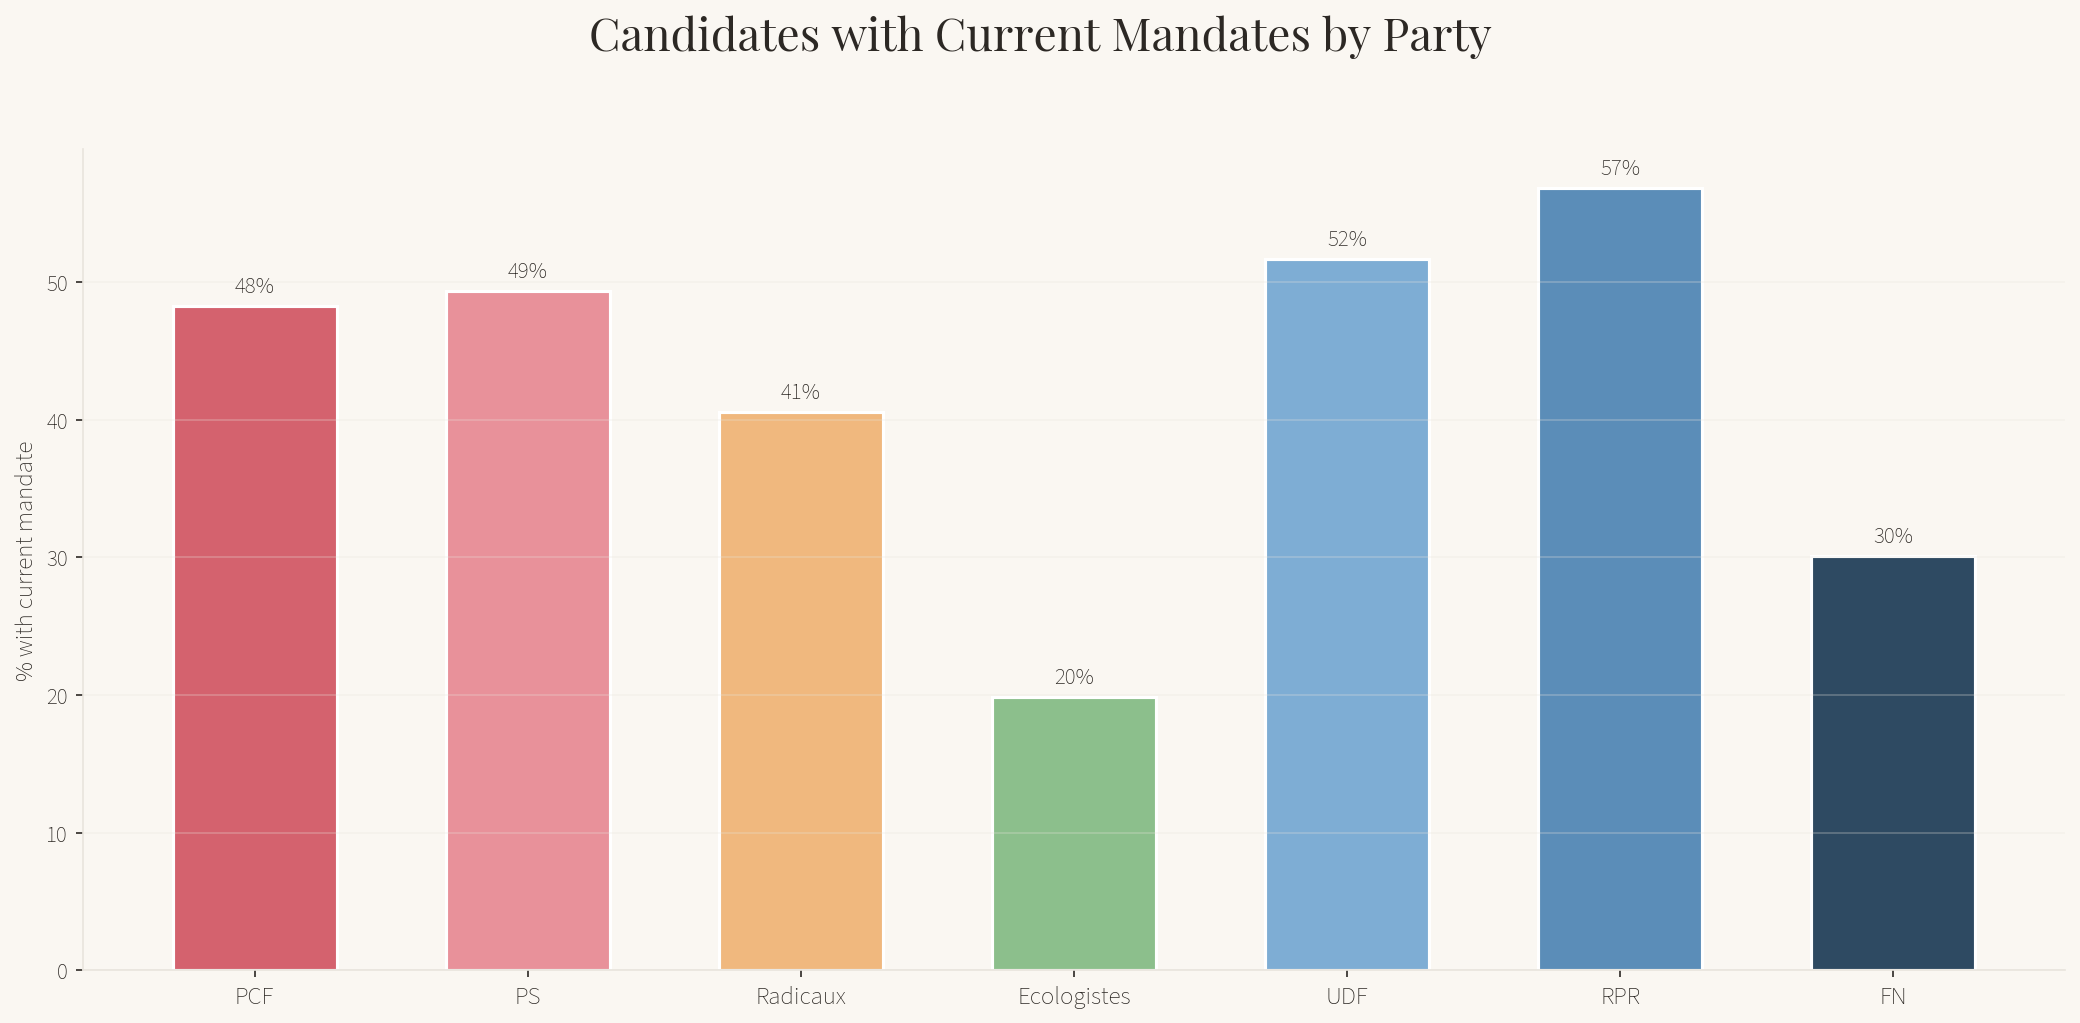

In [26]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Candidates with Current Mandates by Party",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

df_mandats = df[df['parti_famille'].isin(main_parties)].copy()
df_mandats['has_mandat'] = df_mandats['titulaire-mandat-en-cours'].apply(
    lambda x: x if isinstance(x, str) and x.lower() != 'non mentionné' else None)
mandat_rate = df_mandats.groupby('parti_famille')['has_mandat'].apply(
    lambda x: x.notna().mean() * 100).reindex(main_parties)

colors = [PARTY_COLORS.get(p, '#A89F96') for p in main_parties]
bars = ax.bar(range(len(main_parties)), mandat_rate.values, width=0.6,
              color=colors, edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(main_parties)))
ax.set_xticklabels(main_parties, fontsize=12)
ax.set_ylabel("% with current mandate", fontsize=12)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, mandat_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold', color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/mandats_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 9.6 Text length distribution by party (ridge plot)

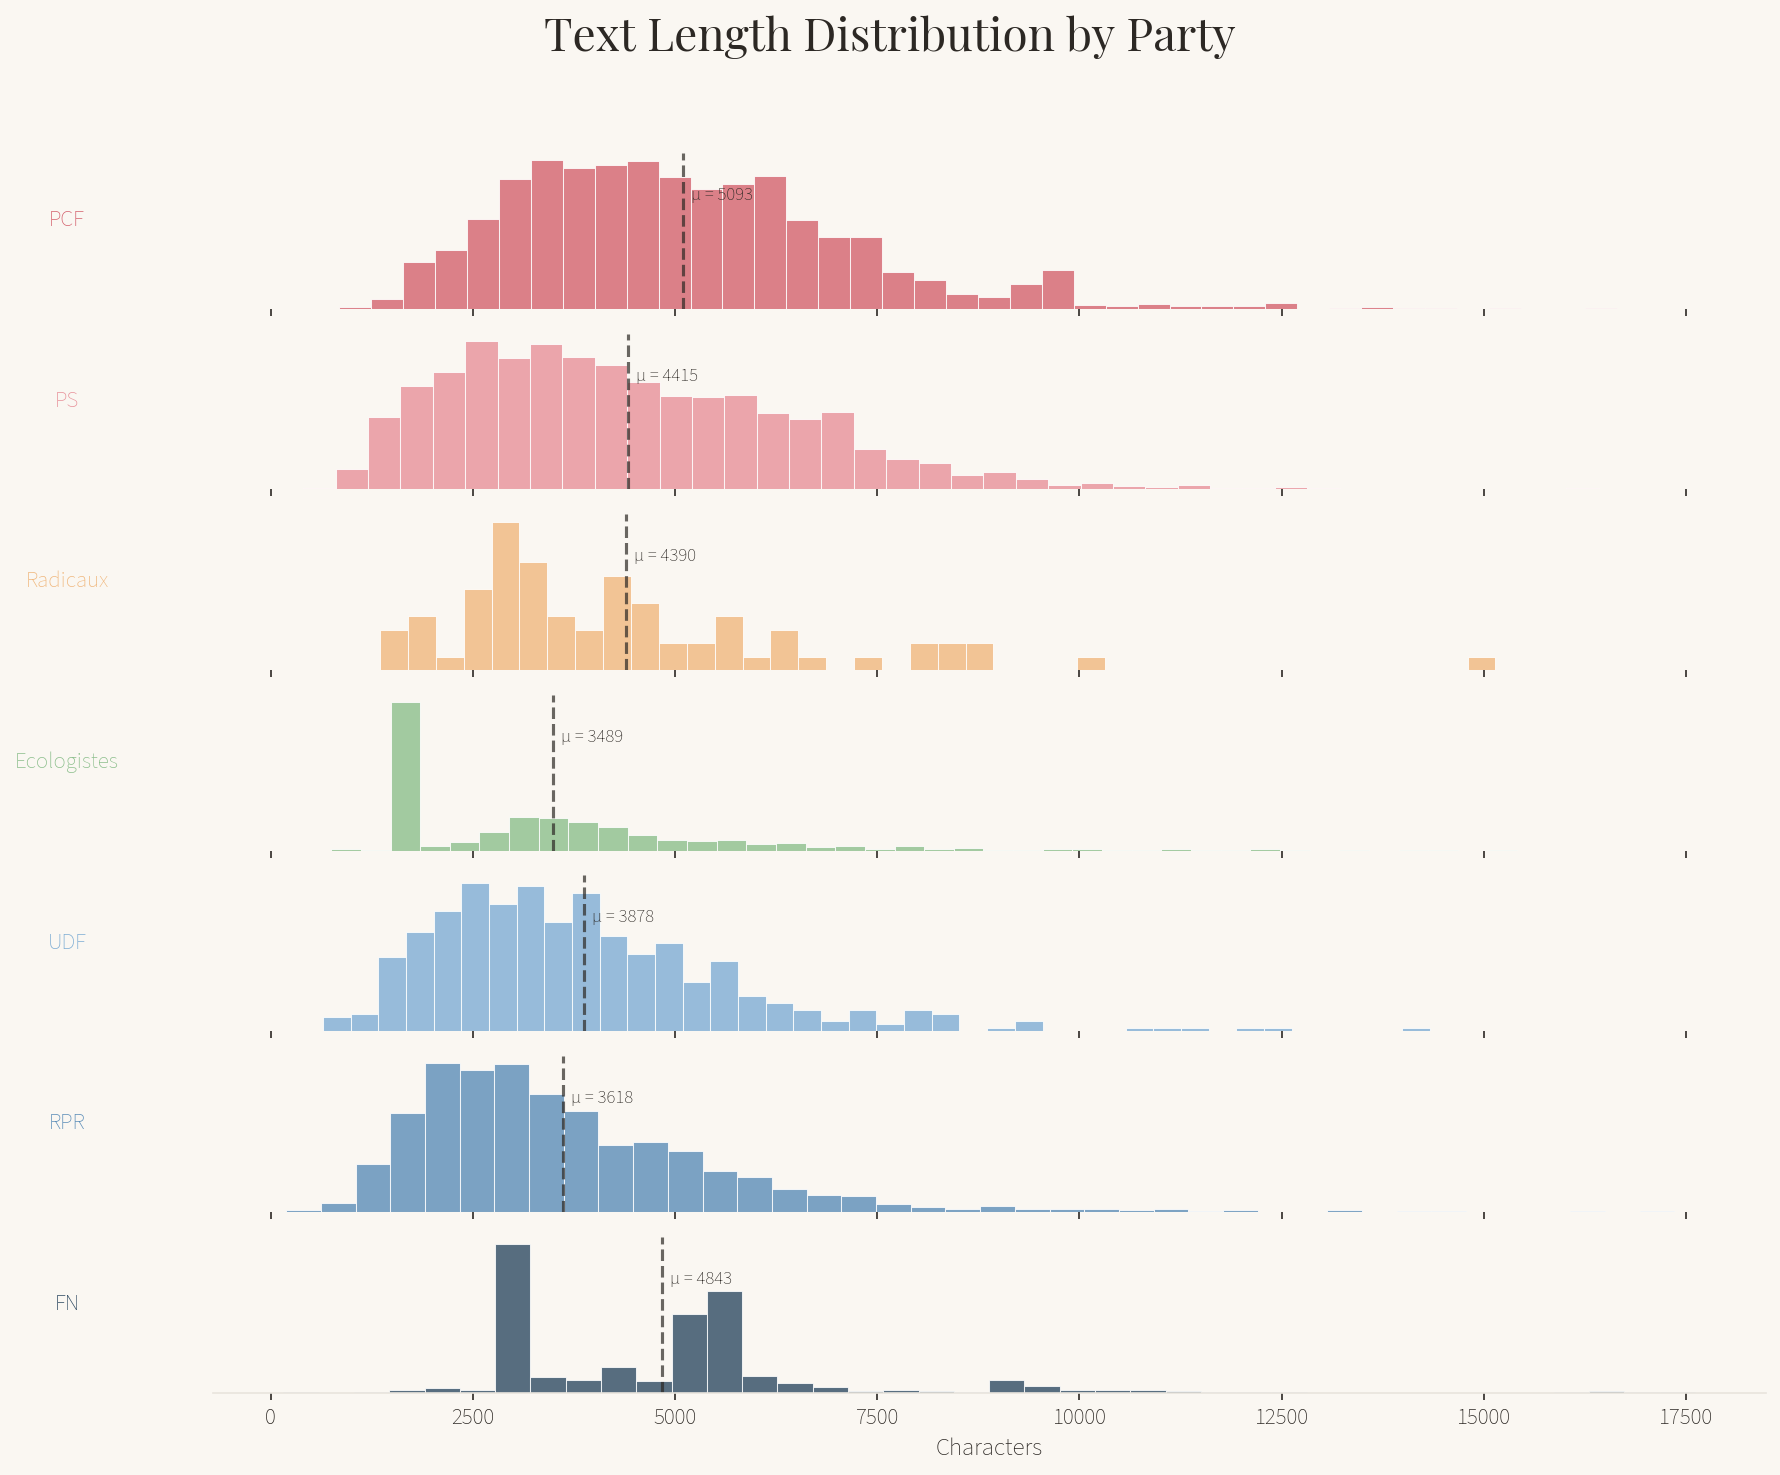

In [27]:
fig, axes = plt.subplots(len(main_parties), 1, figsize=(12, 10), sharex=True)
fig.suptitle("Text Length Distribution by Party",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.98)

for i, party in enumerate(main_parties):
    ax = axes[i]
    data = df[df['parti_famille'] == party]['text_length']
    color = PARTY_COLORS.get(party, '#A89F96')
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(), color=TEXT_COLOR, linewidth=1.5, linestyle='--', alpha=0.7)
    ax.text(data.mean() + 100, ax.get_ylim()[1] * 0.7,
            f'μ = {data.mean():.0f}', fontsize=9, color=TEXT_COLOR)
    ax.set_ylabel(party, fontsize=11, fontfamily=FONT_BODY, fontweight='bold',
                  rotation=0, labelpad=70, color=color)
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

axes[-1].set_xlabel("Characters", fontsize=12)
axes[-1].spines['bottom'].set_visible(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../data/longueur_par_parti.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 9.7 Candidacy trends over time

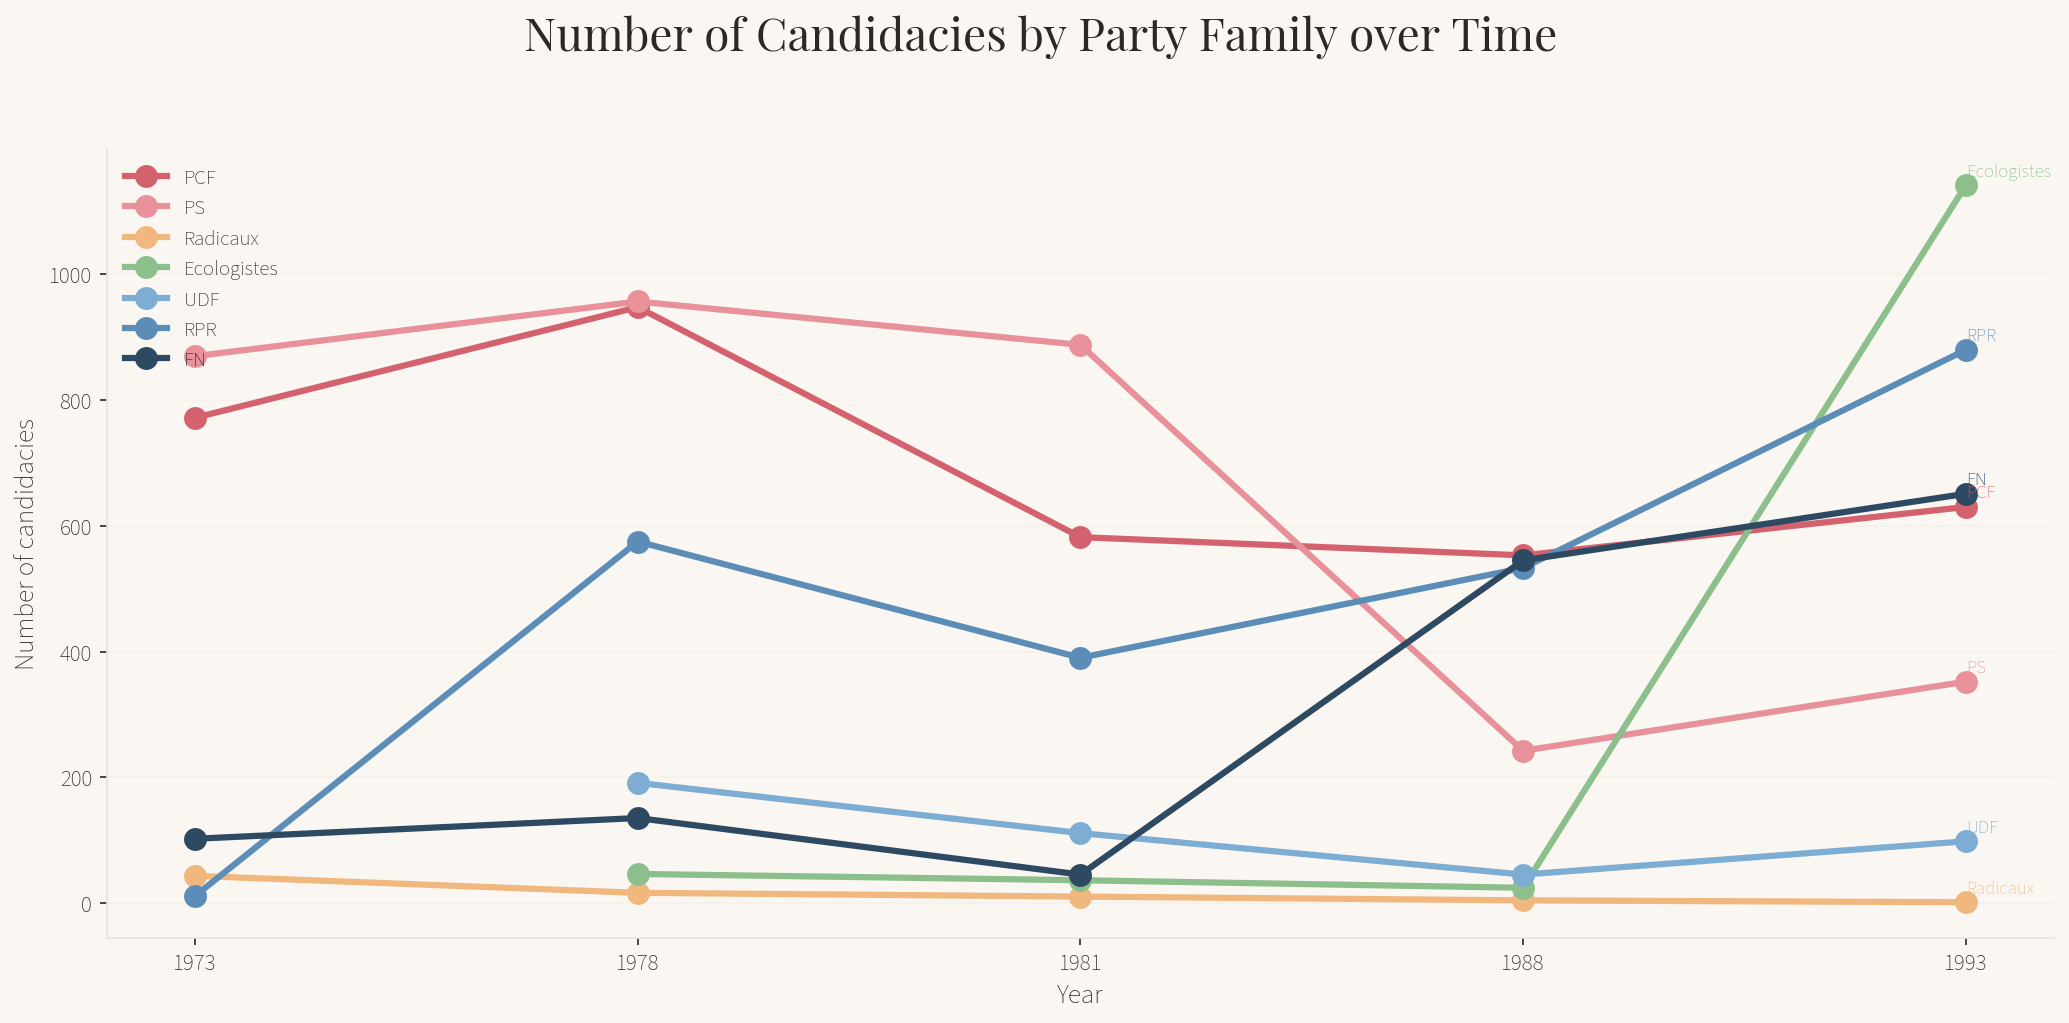

In [28]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Number of Candidacies by Party Family over Time",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

for party in main_parties:
    data = df[df['parti_famille'] == party].groupby('year').size()
    ax.plot(data.index, data.values, marker='o', markersize=10,
            linewidth=3, label=party, color=PARTY_COLORS.get(party, '#A89F96'))
    ax.text(data.index[-1], data.values[-1] + 15, party,
            fontsize=9, color=PARTY_COLORS.get(party, TEXT_COLOR), fontweight='bold')

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Number of candidacies", fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False, fontsize=10, loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/evolution_candidatures.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 9.8 Decorated candidates by party

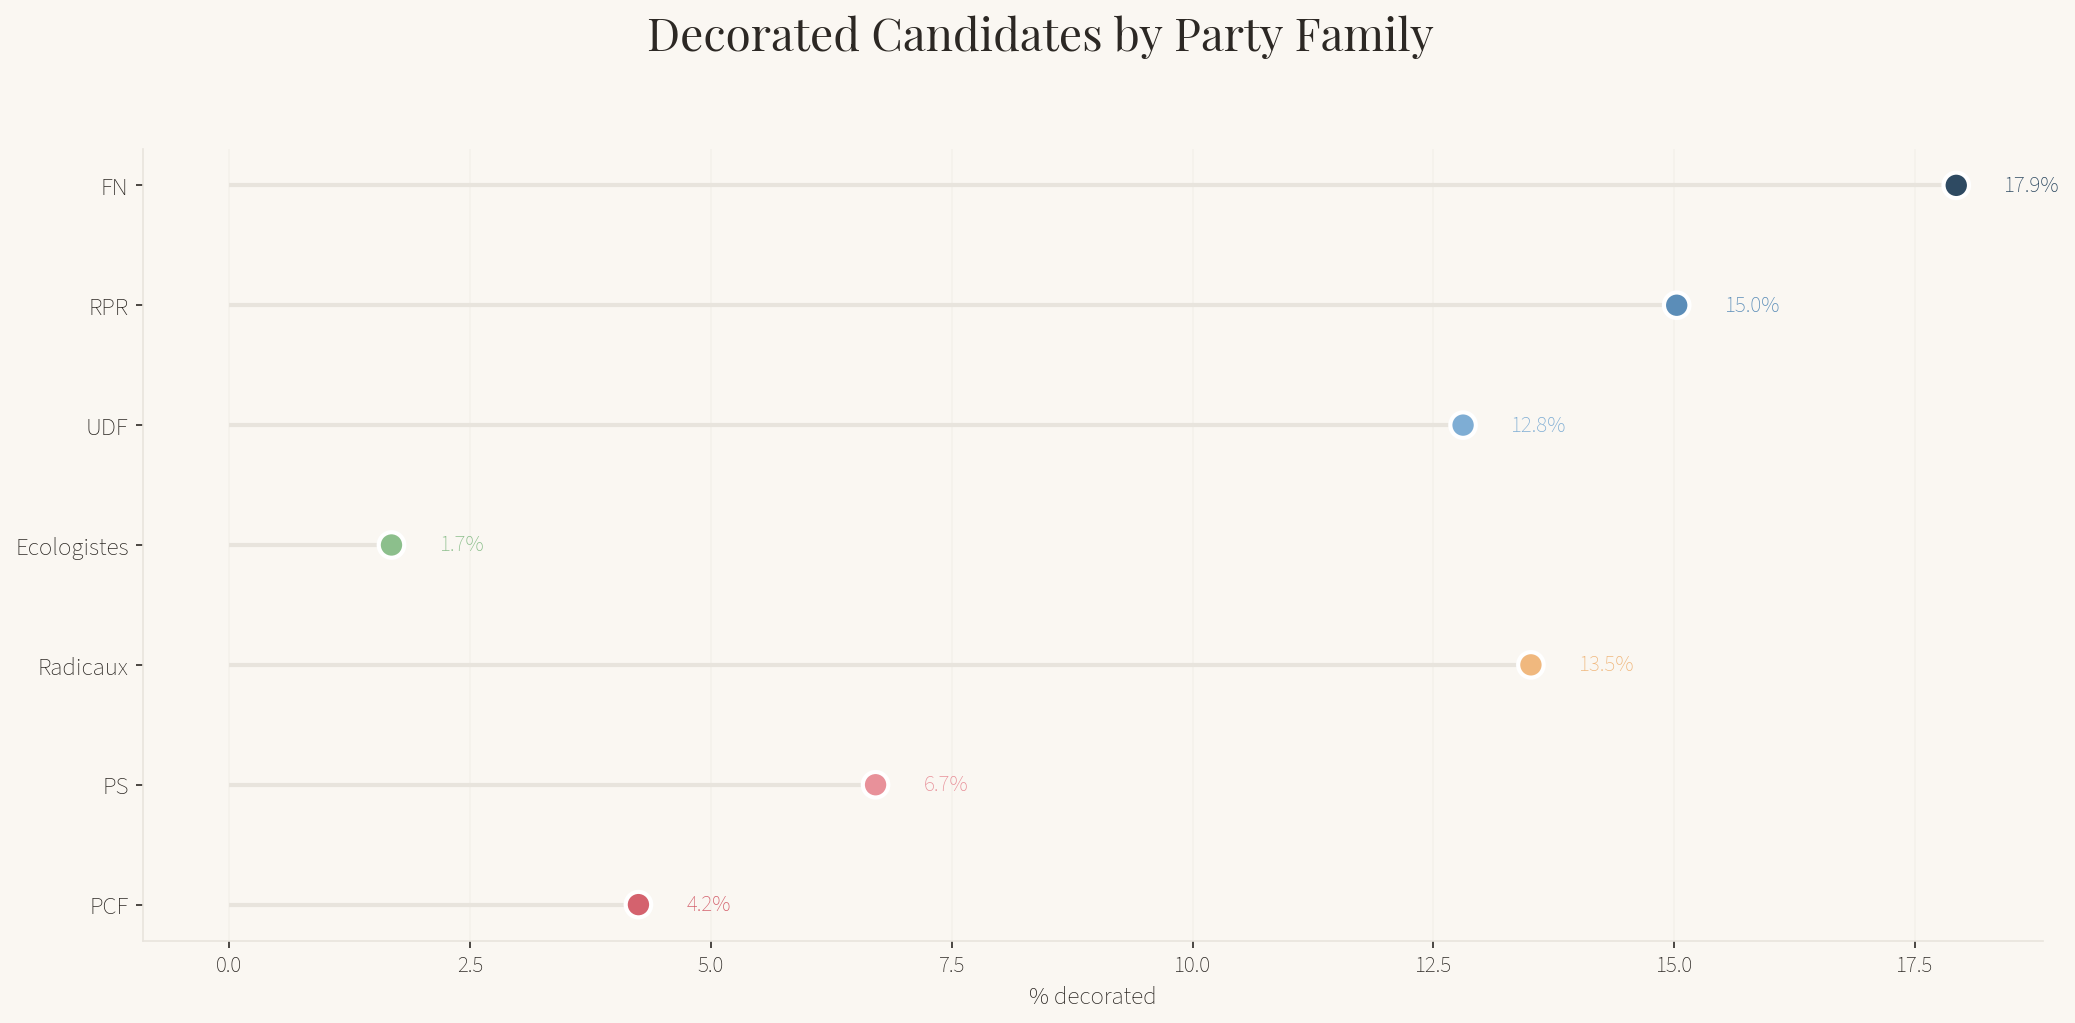

In [29]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Decorated Candidates by Party Family",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

df_deco = df[df['parti_famille'].isin(main_parties)].copy()
df_deco['est_decore'] = df_deco['titulaire-decorations'].apply(
    lambda x: True if isinstance(x, str) and x.lower() not in ['non', 'non mentionné', ''] else False)
deco_rate = df_deco.groupby('parti_famille')['est_decore'].mean().reindex(main_parties) * 100
colors = [PARTY_COLORS.get(p, '#A89F96') for p in main_parties]

ax.hlines(range(len(main_parties)), 0, deco_rate.values, color=GRID_COLOR, linewidth=2)
ax.scatter(deco_rate.values, range(len(main_parties)), s=150, zorder=3,
           color=colors, edgecolors='white', linewidth=2)

for i, (party, val) in enumerate(zip(main_parties, deco_rate.values)):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=11,
            fontweight='bold', color=PARTY_COLORS.get(party, TEXT_COLOR))

ax.set_yticks(range(len(main_parties)))
ax.set_yticklabels(main_parties, fontsize=12, fontfamily=FONT_BODY)
ax.set_xlabel("% decorated", fontsize=12)
ax.spines['bottom'].set_visible(True)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/decorations_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 9.9 PCS evolution over time

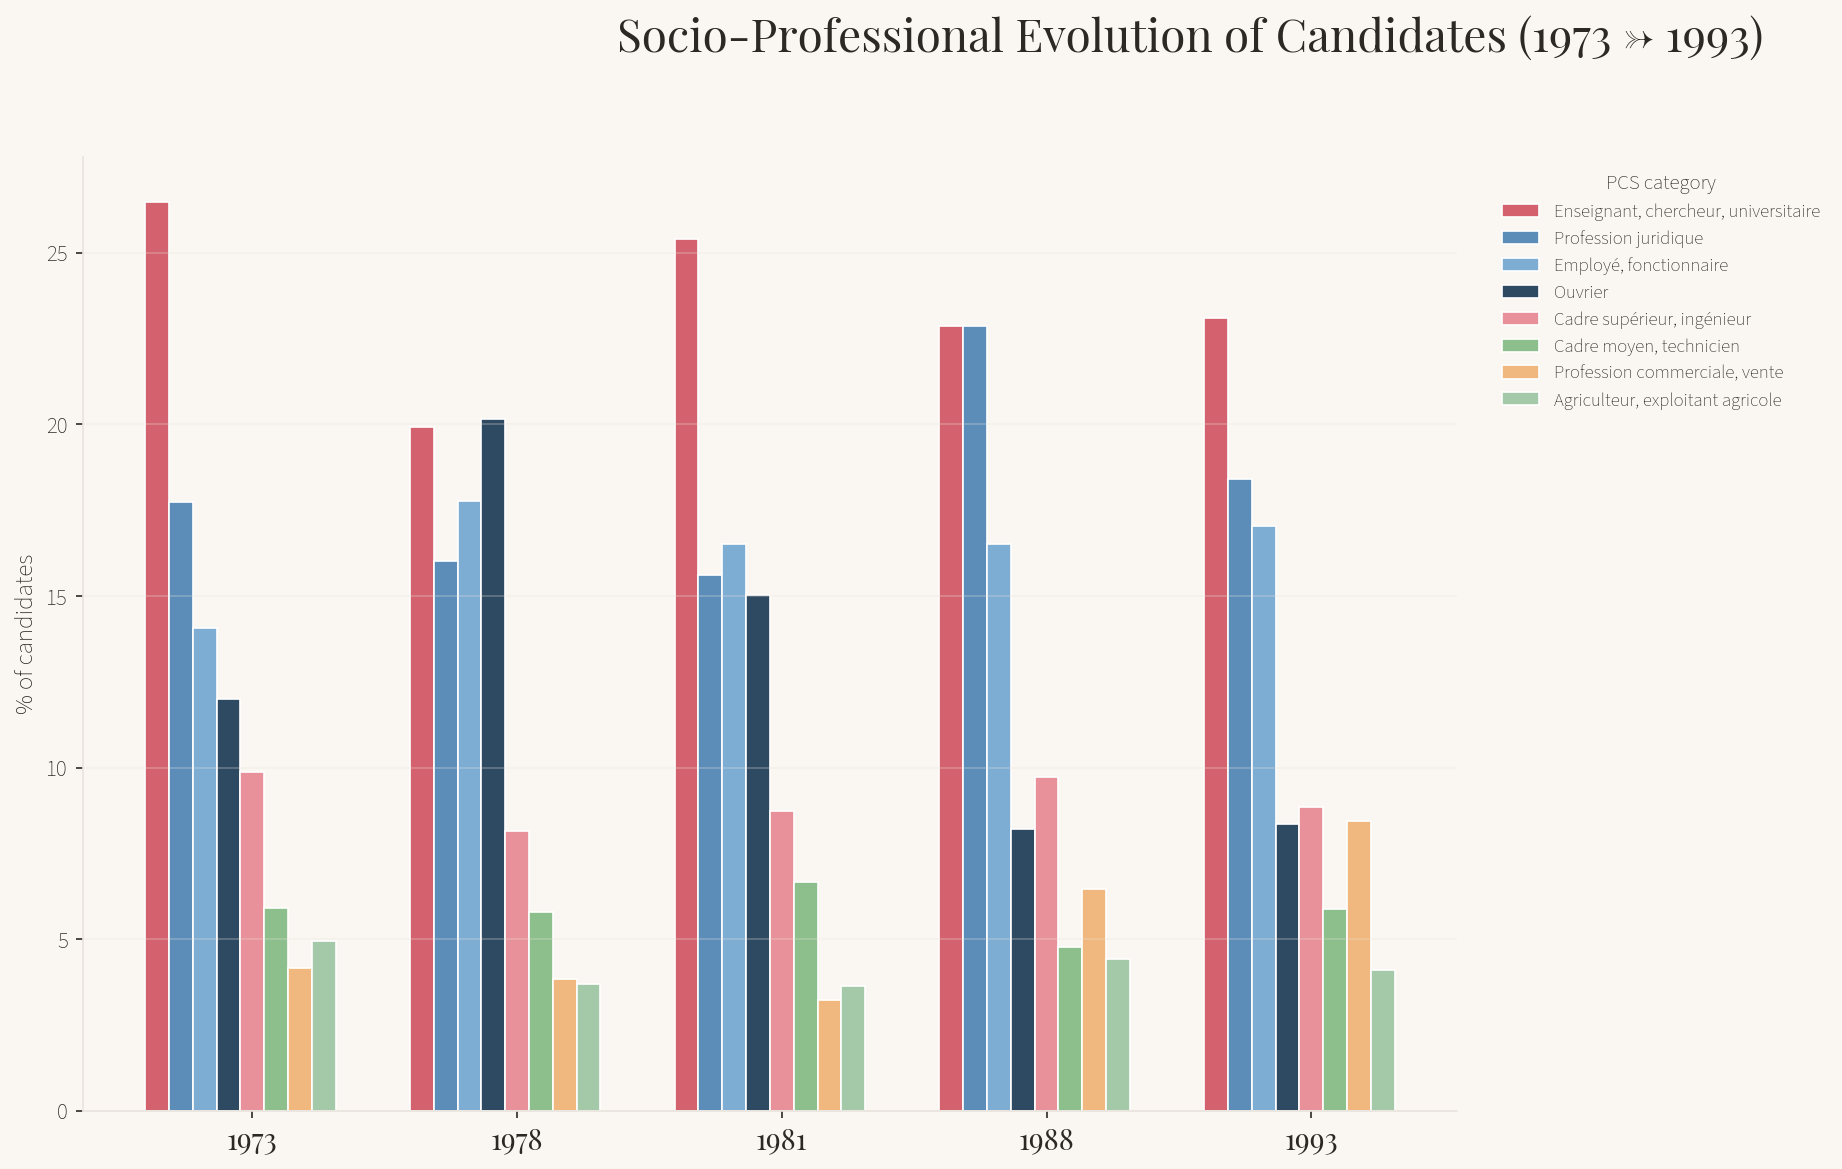

In [30]:
fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle("Socio-Professional Evolution of Candidates (1973 → 1993)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

df_pcs_year = df[df['profession_pcs'] != 'Non renseigné'].copy()
ct = pd.crosstab(df_pcs_year['year'], df_pcs_year['profession_pcs'], normalize='index') * 100
top_pcs = df_pcs_year['profession_pcs'].value_counts().head(8).index.tolist()
ct_top = ct[top_pcs]

x = np.arange(len(ct_top.index))
width = 0.09
n_cat = len(top_pcs)

for i, pcs in enumerate(top_pcs):
    offset = (i - n_cat/2) * width
    color = PCS_COLORS.get(pcs, '#A89F96')
    ax.bar(x + offset, ct_top[pcs], width=width, label=pcs,
           color=color, edgecolor='white', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(ct_top.index, fontsize=14, fontfamily=FONT_TITLE, fontweight='bold')
ax.set_ylabel("% of candidates", fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9,
          title="PCS category", title_fontproperties={'weight': 'bold', 'size': 10})

plt.tight_layout(rect=[0, 0, 0.78, 0.93])
plt.savefig("../data/pcs_evolution.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

---

## 10. Save Enriched Dataset

In [31]:
df.to_pickle("../data/df_explore.pkl")
print(f"Enriched DataFrame saved: {len(df):,} rows × {len(df.columns)} columns")
print(f"New columns: text_clean, tokens, n_tokens, parti_famille, profession_pcs")

Enriched DataFrame saved: 21,697 rows × 52 columns
New columns: text_clean, tokens, n_tokens, parti_famille, profession_pcs


---

## 11. Summary & Next Steps

### What we achieved

| Step | Result |
|------|--------|
| Text cleaning | Lowercased, stripped punctuation/digits, removed stopwords |
| Tokenization | ~350 tokens/document on average |
| Party classification | 9 families from hundreds of raw labels |
| Profession mapping | 15 PCS categories via BERT zero-shot (cached) |
| Visualizations | 15+ publication-quality figures |

### Key findings

- The corpus grows significantly from 1973 to 1993, driven by the FN and ecological parties
- Teachers and legal professionals are massively over-represented among candidates
- The PCF recruits from blue-collar workers; the RPR/UDF from executives and engineers
- Gender parity is extremely low (~10–15% female) across all parties and years

### What comes next

In **Notebook 03 (Topic Modeling)**, we will:
- Build document-term matrices using TF-IDF weighting (as covered in *Chapter I - Vector Representations*)
- Train LDA and NMF models to extract latent themes (following *Chapter VI - Topic Modeling*)
- Analyze thematic specialization by party and temporal evolution of discourse